## BASE INERTIAL PARAMETER ESTIMATION NOTEBOOK

In [22]:
# =========================================================================================================================== Import
import time
import os
import shutil

%matplotlib ipympl
from matplotlib import pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

from scipy.linalg import solve_continuous_lyapunov, block_diag

import numpy as np
from tqdm import tqdm

import pandas as pd

from scipy.signal import butter, filtfilt, savgol_filter
from scipy.linalg import block_diag

import sys
build_paths = ["./ahand_finger_generatedFiles_py/build", "./franka_generatedFiles/build"]
for build_path in build_paths:
    if os.path.exists(build_path):
        sys.path.append(os.path.abspath(build_path))
    else:
        print(f"Warning: path '{build_path}' does not exist.")

from thunder_ahand_finger_py import thunder_ahand_finger
from thunder_franka_py import thunder_franka

MESH_DIR = './description/urdf/meshes/'
URDF_PATH = './description/urdf/allegro_hand_description_right_B.urdf'
XML_PATH = './description/urdf/allegro_hand_description_right_B.xml'
JOINT_NAMES = ['joint_4_0', 'joint_5_0', 'joint_6_0', 'joint_7_0']

np.random.seed(41)


# Dynamic Model

$ (M(q) + \text{diag}(I_r))\ddot{q} + C(q, \dot{q})\dot{q} + G(q) + D \dot{q} + F\text{sign}(\dot{q}) = Y(q, \dot{q}, \ddot{q})\,\pi = \tau $

$ Y(q, \dot{q}, \ddot{q}) \in \mathbb{R}^{n \times 48} $

# Regressor parameters
$ \pi_r^i = \begin{bmatrix} m^i, m^i c^i_x, m^i c^i_x, m^i c^i_x,   J^i_{xx},J^i_{xy},J^i_{xz},J^i_{yy},J^i_{yz},J^i_{zz} \end{bmatrix}'$

$ \pi_d^i = \begin{bmatrix} D^i \end{bmatrix} $

$ \pi_s^i = \begin{bmatrix} F^i \end{bmatrix} $

$ \pi = \begin{bmatrix} \pi^{1'}_r, ..., \pi^{1'}_r | \pi_d^1, ..., \pi_d^n | \pi_s^1, ..., \pi_s^n \end{bmatrix}'$

$ \pi_r \in \mathbb{R}^{40 \times 1}, \pi_d \in \mathbb{R}^{4 \times 1}, \pi_f \in \mathbb{R}^{4 \times 1}$

$ I_r $ = Rotor inertia at joint level ($I_r = N^2 J_r $, $N$: gear ratio, $J_r$: rotor inertia at motor level)

$ D $ = Coloumb friction

$ F $ = Static friction

Output()

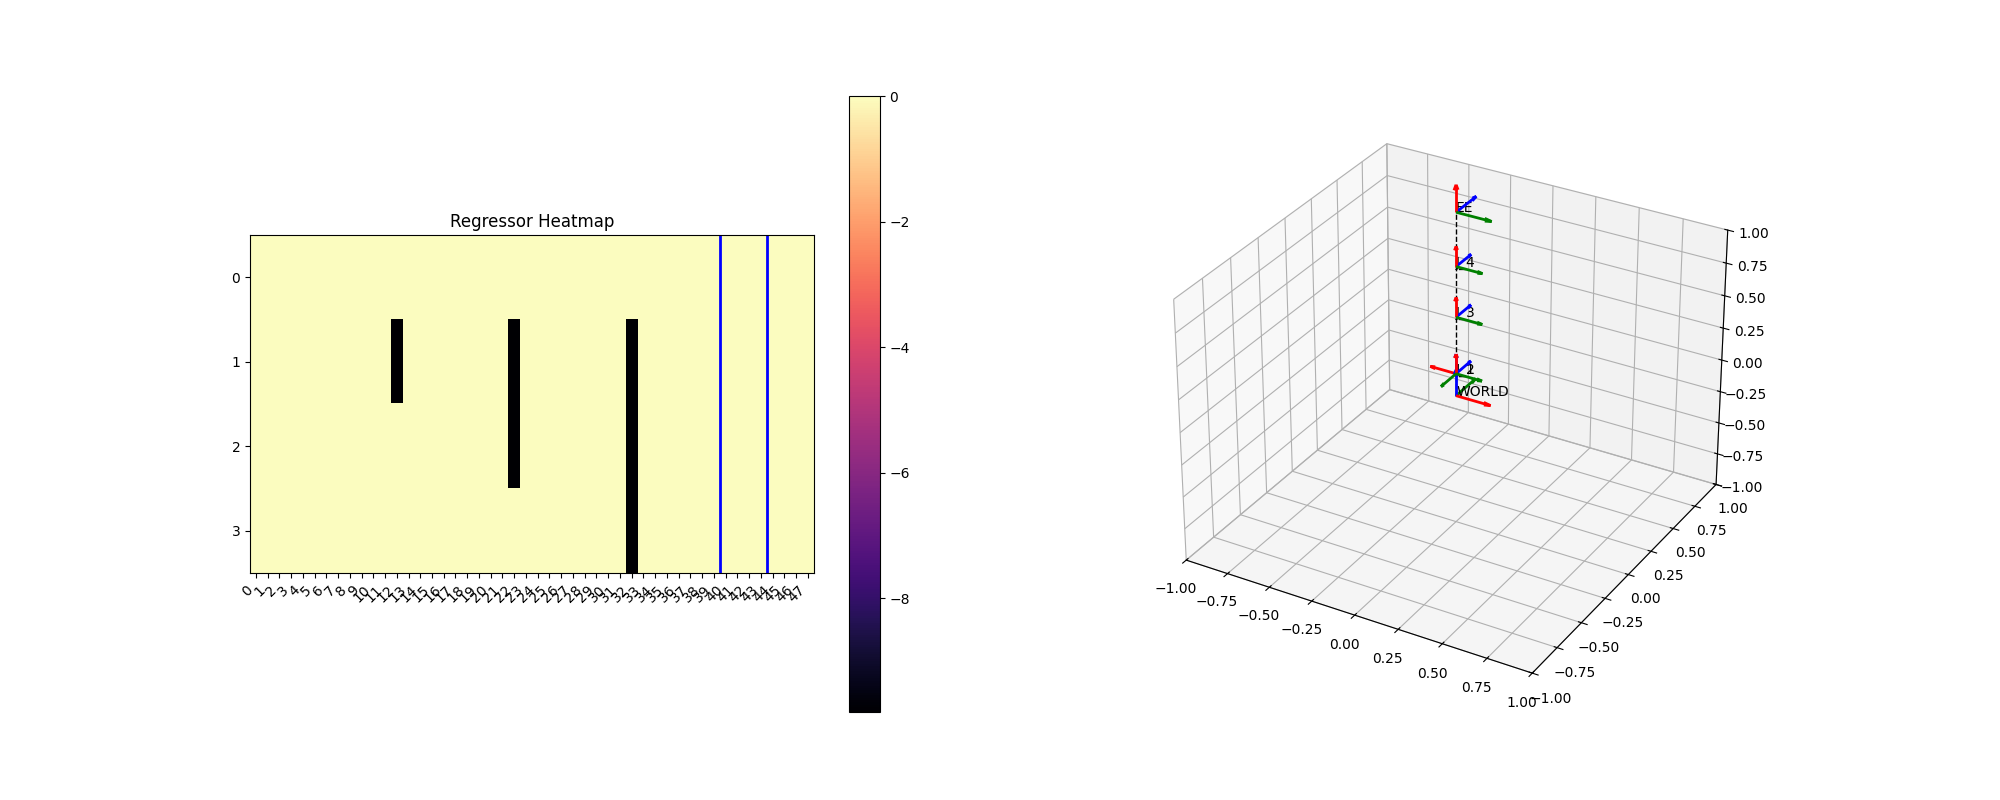

In [11]:
thunder_ahand = thunder_ahand_finger()
thunder_ahand.load_conf("/home/leo/thunder_dynamics/ahand_finger_generatedFiles/ahand_finger_conf.yaml")


# Sliders
q_sliders = [widgets.FloatSlider(value=0, min=-3.14, max=3.14, step=0.01, description=f'q{i}') for i in range(4)]
dq_sliders = [widgets.FloatSlider(value=0, min=-5, max=5, step=0.1, description=f'dq{i}') for i in range(4)]
ddq_sliders = [widgets.FloatSlider(value=0, min=-5, max=5, step=0.1, description=f'ddq{i}') for i in range(4)]

# Group sliders in boxes
q_box = widgets.VBox(q_sliders, layout=widgets.Layout(margin='0 0 10px 0'))
dq_box = widgets.VBox(dq_sliders, layout=widgets.Layout(margin='0 0 10px 0'))
ddq_box = widgets.VBox(ddq_sliders)

# Output widget
out = widgets.Output()


# Create figure and axes once
# --- Figure with two subplots: heatmap + 3D robot ---
fig = plt.figure(figsize=(20,8))
ax_heat = fig.add_subplot(1,2,1)
im = ax_heat.imshow(np.zeros((4,48)), cmap='magma', interpolation='nearest', aspect=0.6*12)
cbar = fig.colorbar(im, ax=ax_heat)
ax_heat.set_title('Regressor Heatmap')
ax_heat.set_xticks(np.arange(48))
ax_heat.set_yticks(np.arange(4))
plt.setp(ax_heat.get_xticklabels(), rotation=45, ha='right')
ax_heat.axvline(x=40-0.5, color='blue', linewidth=2)  # Damping regressor
ax_heat.axvline(x=44-0.5, color='blue', linewidth=2)  # Static regressor
# Annotate initial values
# texts = []
# for i in range(4):
#     row_texts = []
#     for j in range(48):
#         t = ax_heat.text(j, i, f"{0:.2f}", ha='center', va='center', color='black', fontsize=8)
#         row_texts.append(t)
#     texts.append(row_texts)

ax_3d = fig.add_subplot(1,2,2, projection='3d')
ax_3d.set_title('Robot Frames')


def plot_frame(T, ax, name=None, length=0.1):
    origin = T[:3, 3]
    x_axis = T[:3, 0] * length
    y_axis = T[:3, 1] * length
    z_axis = T[:3, 2] * length

    ax.quiver(*origin, *x_axis, color='r', linewidth=2, arrow_length_ratio=0.2)
    ax.quiver(*origin, *y_axis, color='g', linewidth=2, arrow_length_ratio=0.2)
    ax.quiver(*origin, *z_axis, color='b', linewidth=2, arrow_length_ratio=0.2)
    if name:
        ax.text(*origin, name, fontsize=10, color='k')


# Update function
def update(**kwargs):
    q = np.array([kwargs[f'q{i}'] for i in range(4)])
    dq = np.array([kwargs[f'dq{i}'] for i in range(4)])
    ddq = np.array([kwargs[f'ddq{i}'] for i in range(4)])

    thunder_ahand.set_q(q)
    thunder_ahand.set_dq(dq)
    thunder_ahand.set_dqr(dq)
    thunder_ahand.set_ddqr(ddq)
    # Compute regressor
    Y = thunder_ahand.get_reg_M() + thunder_ahand.get_reg_C() + thunder_ahand.get_reg_G()
    Y = thunder_ahand.get_Yr()
    Y_d = np.diag(dq)
    Y_s = np.diag(2/(1+np.exp(-20*dq)) - 1)
    Y = np.hstack([Y, Y_d, Y_s])
    # Compute transform
    frames = [np.eye(4)]  # Base frame
    for i in range(1, thunder_ahand.get_numJoints()+1):
        Ti = getattr(thunder_ahand, f"get_T_0_{i}")()  # Dynamically call robot.get_T_0_i()
        frames.append(Ti)
    frames.append(thunder_ahand.get_T_0_ee())  # End-Effecto frame

    # --- Update heatmap data ---
    im.set_data(Y)
    im.set_clim(vmin=Y.min(), vmax=Y.max())  # adjust color scale if needed
    # # Update annotations
    # for i in range(Y.shape[0]):
    #     for j in range(Y.shape[1]):
    #         texts[i][j].set_text(f"{Y[i,j]:.2f}")

    # --- Update 3D robot plot ---
    ax_3d.cla()  # Clear previous frames
    ax_3d.set_xlim(-1,1)
    ax_3d.set_ylim(-1,1)
    ax_3d.set_zlim(-1,1)
    for i, T in enumerate(frames):
        print(f"T_0_{i}:\n", T[:3, 3])
        if i == 0:
            plot_frame(T, ax_3d, 'WORLD', length=0.2)
        elif i == thunder_ahand.get_numJoints() + 1:
            plot_frame(T, ax_3d, 'EE', length=0.2)
        else:
            plot_frame(T, ax_3d, f'J_{i}', length=0.15)
    origins = np.array([T[:3, 3] for T in frames]) # Connect origins (optional, to show chain)
    ax_3d.plot(origins[:, 0], origins[:, 1], origins[:, 2], 'k--', linewidth=1)
    #for i, p in enumerate(origins):   # --- Add translation labels next to each point 
    #    label = f"({p[0]:.2f}, {p[1]:.2f}, {p[2]:.2f})"
    #    ax_3d.text(p[0], p[1], p[2] + 0.03, label, color='black', fontsize=9)
    
    fig.canvas.draw_idle()

# Combine sliders
all_sliders = {f'q{i}': s for i, s in enumerate(q_sliders)}
all_sliders.update({f'dq{i}': s for i, s in enumerate(dq_sliders)})
all_sliders.update({f'ddq{i}': s for i, s in enumerate(ddq_sliders)})

# Interactive widget
interactive_widget = widgets.interactive(update, **all_sliders)
display(widgets.HBox([q_box, dq_box, ddq_box]), out)

## Objective 
Regroup $\pi_r \rightarrow \hat{\pi}_r$  
s.t.  
$Y(q,\dot{q},\ddot{q})\pi_r = [Y_I(q,\dot{q},\ddot{q}) \;|\; Y_I(q,\dot{q},\ddot{q}) \beta ] \cdot \begin{bmatrix}
                                                                                                            \pi_{I,r} \\
                                                                                                            \pi_{D,r}
                                                                                                        \end{bmatrix}$  
$ \tau = Y_I(\pi_{I,r}+\beta\pi_{I,r}) = Y_I\hat{\pi}_{I,r}$ 


## Grouping inertial parameters by using Energy Model
Considering the $\textbf{Modified Denavit-Hartenberg convention}$ for representing a serial manipulator,  
Let be the inertial parameters vector of the i-th link:
$$ \pi_r^i = \begin{bmatrix} m^i, m^i c^i_x, m^i c^i_x, m^i c^i_x,   J^i_{xx},J^i_{xy},J^i_{xz},J^i_{yy},J^i_{yz},J^i_{zz} \end{bmatrix}'$$
  
Then:  
$$^{i-1}\Lambda_i \in \mathbb{R}^{10 \times 10}$$
s.t.  
$$h_i = h_{i-1}\cdot {}^{i-1}\Lambda_i + \dot{q}_i \nu_i$$
Where  
$h_i: \text{Energy value due to i-th link linear in its dynamic parameters }(L_i = T_i + U_i = h_i \pi_r^i)$  
$\nu_i = [0;\;v_{y,i},\;-v_{x,i},\;0;\;0,\;0,\;\omega_{x,i},\;0,\;\omega_{y,i},\;(\omega_{z,i}-\frac{1}{2}\dot{q}_i) ]$ if ${\color{blue}revolute}$ joint  
$\nu_i = [(v_{z,i}-\frac{1}{2}\dot{q}_i);\;-\omega_{y,i},\;\omega_{x,i},\;0;\;0,\;0,\;0,\;0,\;0,\;0 ]$ if ${\color{red}prismatic}$ joint  
<u>Oss 1</u> $^{i-1}\Lambda_i$ allows to remap the inertial parameters efffect in the previous frame  
<u>Oss 2</u> if $h_i $ is costant the effect of $\pi^i_r$ can be fully remapped on previus link  


Table belows is the explicit value of $^{i-1}\Lambda_i$
<table style="border-collapse: collapse; background-color: white; color:black">
  <tr>
    <th style="border: 1px solid black; padding: 4px;">m</td>
    <th style="border: 1px solid black; padding: 4px;">c<sub>x</sub></td>
    <th style="border: 1px solid black; padding: 4px;">c<sub>y</sub></td>
    <th style="border: 1px solid black; padding: 4px;">c<sub>z</sub></td>
    <th style="border: 1px solid black; padding: 4px;">I<sub>xx</sub></td>
    <th style="border: 1px solid black; padding: 4px;">I<sub>xy</sub></td>
    <th style="border: 1px solid black; padding: 4px;">I<sub>xz</sub></td>
    <th style="border: 1px solid black; padding: 4px;">I<sub>yy</sub></td>
    <th style="border: 1px solid black; padding: 4px;">I<sub>yz</sub></td>
    <th style="border: 1px solid black; padding: 4px;">I<sub>zz</sub></td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 4px;">1</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 4px;">a</td>
    <td style="border: 1px solid black; padding: 4px;">C<span style="color:blue">θ</span></td>
    <td style="border: 1px solid black; padding: 4px;">-S<span style="color:blue">θ</span></td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 4px;">-<span style="color:red">d</span>Sα</td>
    <td style="border: 1px solid black; padding: 4px;">S<span style="color:blue">θ</span>Cα</td>
    <td style="border: 1px solid black; padding: 4px;">C<span style="color:blue">θ</span>Cα</td>
    <td style="border: 1px solid black; padding: 4px;">-Sα</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 4px;"><span style="color:red">d</span>Cα</td>
    <td style="border: 1px solid black; padding: 4px;">S<span style="color:blue">θ</span>Sα</td>
    <td style="border: 1px solid black; padding: 4px;">C<span style="color:blue">θ</span>Sα</td>
    <td style="border: 1px solid black; padding: 4px;">Cα</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 4px;"><span style="color:red">d</span>²</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">2<span style="color:red">d</span></td>
    <td style="border: 1px solid black; padding: 4px;">C²<span style="color:blue">θ</span></td>
    <td style="border: 1px solid black; padding: 4px;">-2CS<span style="color:blue">θ</span></td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">S²<span style="color:blue">θ</span></td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 4px;">a<span style="color:red">d</span>Sα</td>
    <td style="border: 1px solid black; padding: 4px;">-aS<span style="color:blue">θ</span>Cα + <span style="color:red">d</span>C<span style="color:blue">θ</span>Sα</td>
    <td style="border: 1px solid black; padding: 4px;">-aC<span style="color:blue">θ</span>Cα + <span style="color:red">d</span>S<span style="color:blue">θ</span>Sα</td>
    <td style="border: 1px solid black; padding: 4px;">aSα</td>
    <td style="border: 1px solid black; padding: 4px;">CS<span style="color:blue">θ</span>Cα</td>
    <td style="border: 1px solid black; padding: 4px;">(C²<span style="color:blue">θ</span> - S²<span style="color:blue">θ</span>)Cα</td>
    <td style="border: 1px solid black; padding: 4px;">-C<span style="color:blue">θ</span>Sα</td>
    <td style="border: 1px solid black; padding: 4px;">-CS<span style="color:blue">θ</span>Cα</td>
    <td style="border: 1px solid black; padding: 4px;">S<span style="color:blue">θ</span>Sα</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 4px;">-a<span style="color:red">d</span>Cα</td>
    <td style="border: 1px solid black; padding: 4px;">-aS<span style="color:blue">θ</span>Sα - <span style="color:red">d</span>C<span style="color:blue">θ</span>Cα</td>
    <td style="border: 1px solid black; padding: 4px;">-aC<span style="color:blue">θ</span>Sα + <span style="color:red">d</span>S<span style="color:blue">θ</span>Cα</td>
    <td style="border: 1px solid black; padding: 4px;">-aCα</td>
    <td style="border: 1px solid black; padding: 4px;">CS<span style="color:blue">θ</span>Sα</td>
    <td style="border: 1px solid black; padding: 4px;">(C²<span style="color:blue">θ</span> - S²<span style="color:blue">θ</span>)Sα</td>
    <td style="border: 1px solid black; padding: 4px;">-C<span style="color:blue">θ</span>Sα</td>
    <td style="border: 1px solid black; padding: 4px;">-CS<span style="color:blue">θ</span>Sα</td>
    <td style="border: 1px solid black; padding: 4px;">-S<span style="color:blue">θ</span>Sα</td>
    <td style="border: 1px solid black; padding: 4px;">0</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 4px;">a² + <span style="color:red">d</span>²C²α</td>
    <td style="border: 1px solid black; padding: 4px;">2(aC<span style="color:blue">θ</span> + <span style="color:red">d</span>S<span style="color:blue">θ</span>CSα)</td>
    <td style="border: 1px solid black; padding: 4px;">2(-aS<span style="color:blue">θ</span> + <span style="color:red">d</span>C<span style="color:blue">θ</span>CSα)</td>
    <td style="border: 1px solid black; padding: 4px;">2<span style="color:red">d</span>C²α</td>
    <td style="border: 1px solid black; padding: 4px;">S²<span style="color:blue">θ</span>C²α</td>
    <td style="border: 1px solid black; padding: 4px;">2CS<span style="color:blue">θ</span>C²α</td>
    <td style="border: 1px solid black; padding: 4px;">-2S<span style="color:blue">θ</span>CSα</td>
    <td style="border: 1px solid black; padding: 4px;">C²<span style="color:blue">θ</span>C²α</td>
    <td style="border: 1px solid black; padding: 4px;">-2C<span style="color:blue">θ</span>CSα</td>
    <td style="border: 1px solid black; padding: 4px;">s²<span style="color:blue">θ</span></td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 4px;"><span style="color:red">d</span>²CSα</td>
    <td style="border: 1px solid black; padding: 4px;"><span style="color:red">d</span>S<span style="color:blue">θ</span>(S²α-C²α)</td>
    <td style="border: 1px solid black; padding: 4px;"><span style="color:red">d</span>C<span style="color:blue">θ</span>(S²α-C²α)</td>
    <td style="border: 1px solid black; padding: 4px;">2<span style="color:red">d</span>CSα</td>
    <td style="border: 1px solid black; padding: 4px;">S²<span style="color:blue">θ</span>CSα</td>
    <td style="border: 1px solid black; padding: 4px;">2CS<span style="color:blue">θ</span>CSα</td>
    <td style="border: 1px solid black; padding: 4px;">S<span style="color:blue">θ</span>(C²α-s²α)</td>
    <td style="border: 1px solid black; padding: 4px;">C²<span style="color:blue">θ</span>CSα</td>
    <td style="border: 1px solid black; padding: 4px;">c<span style="color:blue">θ</span>(C²α-s²α)</td>
    <td style="border: 1px solid black; padding: 4px;">-CSα</td>
  </tr>
  <tr>
    <td style="border: 1px solid black; padding: 4px;">a² + <span style="color:red">d</span>²S²α</td>
    <td style="border: 1px solid black; padding: 4px;">2(aC<span style="color:blue">θ</span> - <span style="color:red">d</span>S<span style="color:blue">θ</span>CSα)</td>
    <td style="border: 1px solid black; padding: 4px;">2(-aS<span style="color:blue">θ</span> - <span style="color:red">d</span>C<span style="color:blue">θ</span>CSα)</td>
    <td style="border: 1px solid black; padding: 4px;">2<span style="color:red">d</span>S²α</td>
    <td style="border: 1px solid black; padding: 4px;">S²<span style="color:blue">θ</span>S²α</td>
    <td style="border: 1px solid black; padding: 4px;">2CS<span style="color:blue">θ</span>S²α</td>
    <td style="border: 1px solid black; padding: 4px;">2S<span style="color:blue">θ</span>CSα</td>
    <td style="border: 1px solid black; padding: 4px;">C²<span style="color:blue">θ</span>S²α</td>
    <td style="border: 1px solid black; padding: 4px;">2c<span style="color:blue">θ</span>Csα</td>
    <td style="border: 1px solid black; padding: 4px;">C²α</td>
  </tr>
</table>

Note:  
- If i-th joint ${\color{red}prismatic}$ then ${\color{red}d}$ is the joint variable  
- If i-th joint ${\color{blue}revolute}$ then ${\color{blue}\theta}$ is the joint variable

In [34]:
def Lambda(alpha, a, d, theta):
    sa = np.sin(alpha)
    ca = np.cos(alpha)
    st = np.sin(theta)
    ct = np.cos(theta)

    ssa = np.sin(alpha)*np.sin(alpha)
    cca = np.cos(alpha)*np.cos(alpha)
    sst = np.sin(theta)*np.sin(theta)
    cct = np.cos(theta)*np.cos(theta)

    csa = np.cos(alpha)*np.sin(alpha)
    cst = np.cos(theta)*np.sin(theta)

    L = np.zeros((10,10))

    # Mass
    L[:,0] = np.array([1,   a,-d*sa,d*ca,   d**2, a*d*sa, -a*d*ca, a**2 + d**2*cca, d**2*csa, a**2 + d**2*ssa])
    # m*COM
    L[:,1] = np.array([0,   ct, st*ca, st*sa,   0, -a*st*ca + d*ct*sa, -a*st*sa - d*ct*ca, 2*(a*ct + d*st*csa), d*st*(ssa-cca), 2*(a*ct - d*st*csa)])
    L[:,1] = np.array([0,   -st, ct*ca, ct*sa,  0, -a*ct*ca + d*st*sa, -a*ct*sa - d*st*ca, 2*(-a*st + d*ct*csa), d*ct*(ssa-cca), 2*(-a*st - d*ct*csa)])
    L[:,3] = np.array([0,   0, -sa, ca,         2*d, a*sa, -a*ca, 2*d*cca, 2*d*csa, 2*d*ssa])
    # Inertia
    L[:,4] = np.array([0,   0, 0, 0,  cct, cst*ca, cst*sa, sst*cca, sst*csa, sst*ssa])
    L[:,5] = np.array([0,   0, 0, 0,  -2*cst, (cct -sst)*ca, (cct -sst)*sa, 2*cst*cca, 2*cst*csa, 2*cst*ssa])
    L[:,6] = np.array([0,   0, 0, 0,  0, -ct*sa, -ct*sa, -2*st*csa, st*(cca-ssa), 2*st*csa])
    L[:,7] = np.array([0,   0, 0, 0,  sst, -cst*ca, -cst*sa, cct*cca, cct*csa, cct*ssa])
    L[:,8] = np.array([0,   0, 0, 0,  0, st*sa, -st*sa, -2*ct*csa, ct*(cca-ssa), 2*ct*csa])
    L[:,9] = np.array([0,   0, 0, 0,  0, 0, 0, sst, -csa, cca])

    return L


def S(k, n, add_rotor_inertia = False):
    # selettore parametri k s.t. pi_r_k = S_k * pi_r
    S = np.zeros((10, n*10))
    S[:, k*10:(k+1)*10] = np.eye(10)

    if add_rotor_inertia:
        S_I = np.zeros((1, n))
        S_I[:, k] = 1
        S = block_diag(S, S_I)

    return S

In [ ]:


def regrouping(DH, add_rotor_inertia = False):
    start = time.time()
    n = len(DH['joints'])
    pi_r = np.ones((n*10,1))                                    # original regressor parameter vector
    pi_I = np.ones((n,1))                                       # rotor ineria params vector (may be unused)
    if add_rotor_inertia: pi = np.vstack([pi_r, pi_I])
    else: pi = pi_r

    hat_pi_r =[]                                                # reduced parameter vector
    g = np.array([0, 0, -9.81])                                 # gravity vector (<- nice to have from thunder_ahand)

    E = []
    H = []
    W = []

    tolerance = 1e-10                                           # use for zero detection

    # 1_ get r1, r2 and p1, rp1 ------------------
    # a) r1 = first revolute joint
    for i in range(n):
        if DH['joints'][i] == 'R':
            r1 = i
            print("r1 = ", r1)
            break
        if i==n-1:
            print("revolute joint not found.")
            r1 = n
            break
    T_0_r1 = getattr(thunder_ahand, f"get_T_0_{r1+1}")()    # _Oss_. T_0_0 is the world frame not Frame 0
    k_r1 = T_0_r1[0:3,2]                                    # z axis of frame r1 in world frame

    # b) r2 = Next revolute joint not aligned to r1
    for i in range(r1+1,n):
        if DH['joints'][i] == 'R':
            T_0_i = getattr(thunder_ahand, f"get_T_0_{i+1}")()
            k_i = T_0_i[0:3,2]
            if np.abs(k_r1.transpose() @ k_i) < 1 - 1e-14:  # if z_i axis is not aligned to z_r1 axis
                r2 = i
                print("r2 = ", r2)
                break
            if i==n-1:
                r2 = 0
                print("r2 not found")
    T_0_r2 = getattr(thunder_ahand, f"get_T_0_{r2+1}")()    # Oss. T_0_0 is the world frame not Frame 0
    k_r2 = T_0_r2[0:3,2]  # z axis of frame r1 in world frame

    # c) p1 = first prismatic joint
    for i in range(n):
        if DH['joints'][i] == 'P':
            p1 = i
            print("p1 = ", p1)
            break
        if i==n-1:
            print("prismatic joint not found.")
            p1 = -1
            break

    # d) rp1 = Last revolute joint preceding p1
    for i in range(p1-1, -1, -1):
        if DH['joints'][i] == 'R':
            rp1 = i
            print("rp1 = ", rp1)
            break
        elif i==0:
            rp1 = n
            print("rp1 not found")


    # 2_ Select and reduce ------------------------------------
    for i in range(n-1, -1, -1):
        if DH['joints'][i] == 'R':
        #  ----------- REVOLUTE ----------------------------
            # 1) Get i-th param
            S_i = S(i, n, add_rotor_inertia)    # Link param selector
            pi_i = S_i @ pi                 # pi_r_i = [m, cx,cy,cz, I_xx,I_xy,I_xz,I_yy,I_yz,I_zz(, I_r)]'

            # 2) Get type of param reduction (compute E_i)
            E_i = block_diag(1,
                               np.eye(3),
                                        np.array([[1,0,0,-1,0,0],         # regroup I_yy in I_xx
                                                  [0,1,0, 0,0,0],
                                                  [0,0,1, 0,0,0],
                                                  [0,0,0, 1,0,0],
                                                  [0,0,0, 0,1,0],
                                                  [0,0,0, 0,0,1]]))
            print(f"Deleting I_yy, mc_z, m of link {i}...")
            E_i = E_i[[ 1,2, 4,5,6,8,9],:]              # Remove m, m_cz, I_yy
            if add_rotor_inertia: 
                E_i =  block_diag(E_i, 1)               # (add rotor inertia block if needed)

            if add_rotor_inertia and i == r2 and np.abs(k_r2 @ k_r1) < tolerance:
                print(f"Deleting I_r of link {i}...")
                # r2 joint axis orthogonal to r1 joint axis
                E_i[6,10] = 1       # regroup I_r in I_zz
                E_i = E_i[0:7,:]          # Remove I_r
            if add_rotor_inertia and i == r1:
                print(f"Deleting I_r of link {i}...")
                # joint r1
                E_i[6,10] = 1       # regroup I_r in I_zz
                E_i = E_i[0:7,:]          # Remove I_r

            if r1<=i and i<r2:
                print(f"Deleting I_xx, I_xy, I_xz, I_yz of link {i}...")
                E_i = np.vstack([E_i[[ 0,1],:], E_i[6:,:]])                     # remove I_xx, I_xy, I_xz, I_yz


                T_0_i = getattr(thunder_ahand, f"get_T_0_{i+1}")()
                k_i = T_0_i[0:3,2]      # z axis of frame i in world frame
                k_r1 = T_0_r1[0:3,2]    # z axis of frame r1 in world frame
                k_g = g/np.linalg.norm(g)

                if np.abs(k_i.transpose() @ k_r1) > 1 - tolerance:  # if z_i axis aligned to z_r1 axis
                    for j in range(i):
                        k_j = getattr(thunder_ahand, f"get_T_0_{j+1}")()[0:3,2]
                        print("k_j:", k_j)
                        if not(np.abs(k_j.transpose() @ k_r1) > 1 - tolerance and np.abs(k_j.transpose() @ k_g) > 1 - tolerance): # if NOT z_j axis aligned to z_r1 axis and to gravity
                            break
                        if j==i-1:
                            print(f"Deleting mc_x, mc_y of link {i}...")
                            E_i = E_i[2:,:]                                               # remove mc_x, mc_y

            hat_pi_i = E_i @ pi_i.reshape(-1, 1)  # Extracting reduced params from i-th link

            # 3) Remapping on previous link (compute H_iminus)
            if i>0:
                iminus_L_i = Lambda(DH['alpha'][i], DH['a'][i], DH['d'][i], DH['theta'][i])
                if not(add_rotor_inertia):
                    # -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                    #                           m,                               cx,cy,        cz,                             I_xx,I_xy,I_xz,               I_yy,                                I_yz,I_zz,     |     pi_r
                    # -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                    H_iminus = np.hstack([iminus_L_i[:,0].reshape(-1, 1),  np.zeros((10,2)),iminus_L_i[:,3].reshape(-1, 1),  np.zeros((10,3)),(iminus_L_i[:,4] + iminus_L_i[:,7]).reshape(-1, 1),np.zeros((10,2)), np.eye(10)])
                    pi[10*(i-1):10*i,:] = H_iminus @ np.vstack([pi_i,
                                                                S(i-1,n)@pi])
                else:
                    # -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                    #                                                m,                      cx,cy,        cz,                          I_xx,I_xy,I_xz,               I_yy,                                  I_yz,I_zz,Ir   |      pi_r, pi_I
                    # -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                    H_iminus = np.vstack([np.hstack([iminus_L_i[:,0].reshape(-1, 1),  np.zeros((10,2)),iminus_L_i[:,3].reshape(-1, 1),  np.zeros((10,3)),(iminus_L_i[:,4] + iminus_L_i[:,7]).reshape(-1, 1),np.zeros((10,3)), np.eye(10), np.zeros((10,1))]),
                                          np.array([             0,                           0,0,         0,                              0,0,0,                       0,                                       0,0,0,        0,0,0,0,0,0,0,0,0,0,1])])

                    tmp = H_iminus @ np.vstack([pi_i,
                                                S(i-1,n, add_rotor_inertia) @ pi])
                    pi[10*(i-1):10*i,:] = tmp[:10,:]
                    pi[10*n + i,:] = tmp[10,:]

            # 4) Get relationship parameters-reduced parameter i-th (Compute of W_i)
            if i==n-1:
                # last link
                W_i = S_i
                H_i = np.eye(10)
                if (add_rotor_inertia): H_i = block_diag(H_i, 1)
                H = [H_i] + H
            else:
                H_i = H[0]
                H_iplus = H[1]
                W_iplus = W[0]
                W_i = np.vstack([H_iplus @ W_iplus,
                                 S_i])
            if i>0:  H = [H_iminus] + H
            W = [W_i] + W
            E = [E_i] + E


            hat_pi_r = hat_pi_i.flatten().tolist() + hat_pi_r

        #  ----------- PRISMATIC ----------------------------
        elif DH['joints'][i] == 'P':
            # 1) Get i-th param
            S_i = S(i, n, add_rotor_inertia)                   # param selector
            pi_i = S_i @ pi                                    # pi_r_i = [m, cx,cy,cz, I_xx,I_xy,I_xz,I_yy,I_yz,I_zz(, Ir)]

            # 2) Get type of param reduction (compute E_i)
            E_i = np.eye(10)
            print(f"Deleting I_xx, I_xy, I_xz, I_yy, I_yz, I_zz of link {i}...")
            E_i = E_i[0:4,:]

            if r1 < i and  i < r2:
                T_0_i = getattr(thunder_ahand, f"get_T_0_{i+1}")()
                k_i = T_0_i[0:3,2]      # z axis of frame i in world frame
                k_r1 = T_0_r1[0:3,2]    # z axis of frame r1 in world frame
                k_g = g/np.linalg.norm(g)

                if np.abs(k_i.transpose() @ k_r1) > 1 - tolerance:       # if z_i axis parallel to z_r1 axis
                    print(f"Deleting mc_z of link {i}...")
                    E_i = E_i[0:3,:]                        # remove mc_z

                else:                                                    # if z_i axis is not parallel to z_r1 axis
                    T_i_r1 = np.linalg.inv(T_0_i) @ T_0_r1
                    i_k_r1 = T_i_r1[0:3,2]
                    if i_k_r1[3] > tolerance:
                        E_i[1,3] = -i_k_r1[1] / i_k_r1[3]     # Regroup mc_z in mc_x
                        E_i[2,3] = -i_k_r1[2] / i_k_r1[3]     # Regroup mc_z in mc_x
                        E_i = E_i[0:3,:]                        # remove mc_z
                    elif i_k_r1[0] > tolerance and i_k_r1[1] > tolerance:
                        E_i[1,3] = -i_k_r1[1] / i_k_r1[2]     # Regroup mc_y in mc_x
                        E_i = E_i[[0,1,3],:]                    # remove mc_y
                    elif i_k_r1[2] > tolerance :
                        E_i = E_i[[0,1,3],:]                    # remove mc_y
                    else:
                        E_i = E_i[[0,2,3],:]                    # remove mc_x
            elif i < r1:
                print(f"Deleting mc_x, mc_y, mc_z of link {i}...")
                E_i = E_i[0,0]                                                      # remove mc_x, mc_y, mc_z


            if add_rotor_inertia: E_i =  block_diag(E_i, 1)               # (add rotor inertia block if needed)
            if add_rotor_inertia and i == p1:
                T_0_p1 = getattr(thunder_ahand, f"get_T_0_{p1+1}")()    # Oss. T_0_0 is the world frame not Frame 0
                k_p1 = T_0_p1[0:3,2]  # z axis of frame r1 in world frame
                T_0_rp1 = getattr(thunder_ahand, f"get_T_0_{rp1+1}")()    # Oss. T_0_0 is the world frame not Frame 0
                k_rp1 = T_0_rp1[0:3,2]  # z axis of frame r1 in world frame
                k_g = g/np.linalg.norm(g)
                if (np.abs(k_p1.transpose() @ k_g) < tolerance) and (p1 == 1 or  np.abs(k_p1.transpose() @ k_rp1) > 1 - tolerance):
                    print(f"Deleting I_r of link {i}...")
                    # r2 joint axis orthogonal to r1 joint axis
                    E_i[0,10] = 1       # regroup I_r in m
                    E_i[:-1,:]          # Remove I_r

            hat_pi_i = E_i @ pi_i.reshape(-1, 1)  # Extracting reduced params from i-th link

            # 3) Remapping on previous link (compute H_iminus)
            if i>0:
                iminus_L_i = Lambda(DH['alpha'][i], DH['a'][i], DH['d'][i], DH['theta'][i])
                if not(add_rotor_inertia):
                    # ------------------------------------------------------------------------------------------
                    #                      m, cx,cy,cz,      I_xx,I_xy,I_xz,I_yy,I_yz,I_zz,     |     pi_r
                    # ------------------------------------------------------------------------------------------
                    H_iminus = np.hstack([np.zeros((10,4)),     iminus_L_i[:,4:10],                 np.eye(10)])
                    pi[10*(i-1):10*i,:] = H_iminus @ np.vstack([pi_i,
                                                                S(i-1,n)@pi])
                else:
                    # -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                    #                               m,cx,cy,cz,         I_xx,I_xy,I_xz,I_yy,I_yz,I_zz,           Ir          |      pi_r, pi_I
                    # -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                    H_iminus = np.vstack([np.hstack([np.zeros((10,4)),     iminus_L_i[:,4:10],             np.zeros((10,1)),    np.eye(10), np.zeros((10,1))]),
                                          np.array( [ 0,0,0,0,             0,0,0,0,0,0,                           0,            0,0,0,0,0,0,0,0,0,0,1])])

                    tmp = H_iminus @ np.vstack([pi_i,
                                                S(i-1,n, add_rotor_inertia) @ pi])
                    pi[10*(i-1):10*i,:] = tmp[:10,:]
                    pi[10*n + i,:] = tmp[10,:]


            # 4) Get relationship parameters-reduced parameter i-th (Compute of W_i)
            if i==n-1:
                # last link
                W_i = S_i
                H_i = np.eye(10)
                if (add_rotor_inertia): H_i = block_diag(H_i, 1)
                H = [H_i] + H
            else:
                H_i = H[0]
                H_iplus = H[1]
                W_iplus = W[0]
                W_i = np.vstack([H_iplus @ W_iplus,
                                 S_i])
            if i>0:  H = [H_iminus] + H
            W = [W_i] + W
            E = [E_i] + E


            hat_pi_r = hat_pi_i.flatten().tolist() + hat_pi_r

    beta = []
    for i in range(n):
        beta.append(E[i] @ H[i] @ W[i])
    beta = np.vstack(beta)

    # ----- Final reporting
    end = time.time()
    if add_rotor_inertia: print(f"Regrouping completed in {1000*(end - start)} ms. Parameters reduced from {len(pi_r.tolist())+len(pi_I.tolist())} to ", len(hat_pi_r))
    else: print(f"Regrouping completed in {1000*(end - start)} ms. Parameters reduced from {len(pi_r.tolist())} to ", len(hat_pi_r))



    return hat_pi_r, beta

## ALLEGRO HAND FINGER TEST

In [111]:
_,beta =regrouping(DH, True)
beta_pinv = np.linalg.pinv(beta)

pi = np.zeros((44,1)) # rotor inertia
pi[9] = 1
pi[19] = 1
pi[41] = 1
pi[40] = 1
print(pi.transpose())
print((beta@pi).transpose())

Y = thunder_ahand.get_Yr()
Y_I = np.diag([0,0,0,0])
Y = np.hstack([Y, Y_I])
Y_trim = Y[:,[1,2,      9        ,11,12 ,14,15,16 ,18,19,     21,22 ,24,25,26 ,28,29,42      ,31,32 ,34,35,36 ,38,39,43]]
Y_red = Y @ beta_pinv
print(Y_trim.shape)
print(Y_red.shape)


#print(beta@pi)

r1 =  0
r2 =  1
No prismatic joint found.
Deleting I_yy, mc_z, m of link 3...
Deleting I_yy, mc_z, m of link 2...
Deleting I_yy, mc_z, m of link 1...
Deleting I_r of link 1...
Deleting I_yy, mc_z, m of link 0...
Deleting I_r of link 0...
Deleting I_xx, I_xy, I_xz, I_yz of link 0...
Regrouping completed in 1.6376972198486328 ms. Parameters reduced from 44 to  26
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0.]]
[[0. 0. 2. 0. 0. 0. 0. 0. 0. 2. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0.]]
(4, 26)
(4, 26)


In [ ]:
#       X       X  X  X  X  X  X             X       X           X              X       X           X             X       X           X            X  X
#       m,mx,my,mz,xx,xy,xz,yy,yz,zz         m,mx,my,mz,xx,xy,xz,yy,yz,zz       m,mx,my,mz,xx,xy,xz,yy,yz,zz      m,mx,my,mz,xx,xy,xz,yy,yz,zz     i0,i1,i2,i3
#Y[:,[  0, 1, 2, 3, 4, 5, 6, 7, 8, 9,       10,11,12,13,14,15,16,17,18,19,     20,21,22,23,24,25,26,27,28,29,    30,31,32,33,34,35,36,37,38,39,    40,41,42,43]]
TEST_WITH_ROTOR = True
TOLERANCE = 1e-10

if TEST_WITH_ROTOR:_,beta =regrouping(DH, True)
else:   _,beta =regrouping(DH)

beta_pinv = np.linalg.pinv(beta)

thunder_ahand = thunder_ahand_finger()
thunder_ahand.load_conf("/home/leo/thunder_dynamics/ahand_finger_generatedFiles/ahand_finger_conf.yaml")

if TEST_WITH_ROTOR: pi = 100*np.random.rand(44,1) # rotor inertia
else: pi = 100*np.random.rand(40,1) # no rotor


print(f"Params: {pi.transpose()}")
print(f"beta: {np.array2string(beta, precision=3, floatmode='fixed',suppress_small=True)}")
print(f"beta_pinv: {np.array2string(beta_pinv, precision=3, floatmode='fixed',suppress_small=True)}")
pi_reduced = beta @ pi

# Sliders
q_sliders = [widgets.FloatSlider(value=0, min=-3.14, max=3.14, step=0.01, description=f'q{i}') for i in range(4)]
dq_sliders = [widgets.FloatSlider(value=0, min=-5, max=5, step=0.1, description=f'dq{i}') for i in range(4)]
ddq_sliders = [widgets.FloatSlider(value=0, min=-5, max=5, step=0.1, description=f'ddq{i}') for i in range(4)]

# Group sliders in boxes
q_box = widgets.VBox(q_sliders, layout=widgets.Layout(margin='0 0 10px 0'))
dq_box = widgets.VBox(dq_sliders, layout=widgets.Layout(margin='0 0 10px 0'))
ddq_box = widgets.VBox(ddq_sliders)

# Output widget
out = widgets.Output()


# Update function
def update(**kwargs):
    q = np.array([kwargs[f'q{i}'] for i in range(4)])
    dq = np.array([kwargs[f'dq{i}'] for i in range(4)])
    ddq = np.array([kwargs[f'ddq{i}'] for i in range(4)])

    thunder_ahand.set_q(q)
    thunder_ahand.set_dq(dq)
    thunder_ahand.set_dqr(dq)
    thunder_ahand.set_ddqr(ddq)
    # Compute regressor
    Y = thunder_ahand.get_Yr()
    Y_I = np.diag(ddq.flatten())
    if TEST_WITH_ROTOR: Y = np.hstack([Y, Y_I])

    if np.linalg.matrix_rank(beta) < beta.shape[0]:
        print(f"Warning: Regressor matrix is rank deficient ({np.linalg.matrix_rank(beta)}).")

    Y_hat = Y @ np.linalg.pinv(beta)

    with out:
        out.clear_output()
        #       X       X  X  X  X  X  X             X       X           X              X       X           X             X       X           X            X  X
        #       m,mx,my,mz,xx,xy,xz,yy,yz,zz         m,mx,my,mz,xx,xy,xz,yy,yz,zz       m,mx,my,mz,xx,xy,xz,yy,yz,zz      m,mx,my,mz,xx,xy,xz,yy,yz,zz     i0,i1,i2,i3
        #Y[:,[  0, 1, 2, 3, 4, 5, 6, 7, 8, 9,       10,11,12,13,14,15,16,17,18,19,     20,21,22,23,24,25,26,27,28,29,    30,31,32,33,34,35,36,37,38,39,    40,41,42,43]]
        if TEST_WITH_ROTOR: Y_err = Y[:,[  1,2,      9        ,11,12 ,14,15,16 ,18,19,     21,22 ,24,25,26 ,28,29,42      ,31,32 ,34,35,36 ,38,39,43]] - Y_hat       # with rotor
        else: Y_err = Y[:,[  1,2,      9        ,11,12 ,14,15,16 ,18,19     ,21,22 ,24,25,26 ,28,29      ,31,32 ,34,35,36 ,38,39]] - Y_hat

        error = (Y@pi - Y_hat @ pi_reduced).transpose()
        if np.max(np.abs(Y_err)) > TOLERANCE:
            print("\033[91m" + "Y Error: " + np.array2string(Y_err,
                                                precision=3,
                                                floatmode='fixed',
                                                suppress_small=True) + "\033[0m")
        else:
            print("Y Error: " + np.array2string(Y_err,
                                                precision=3,      # number of decimals
                                                floatmode='fixed',
                                                suppress_small=True))
        if np.linalg.norm(error) > TOLERANCE:
            print("\033[91m" + "Tau Error: " + np.array2string(  error,
                                                precision=3,
                                                floatmode='fixed',
                                                suppress_small=True) + "\033[0m")
        else:
            print("Tau Error: " + np.array2string(  error,
                                                precision=3,      # number of decimals
                                                floatmode='fixed',
                                                suppress_small=True))

# Combine sliders
all_sliders = {f'q{i}': s for i, s in enumerate(q_sliders)}
all_sliders.update({f'dq{i}': s for i, s in enumerate(dq_sliders)})
all_sliders.update({f'ddq{i}': s for i, s in enumerate(ddq_sliders)})

# Interactive widget
interactive_out = widgets.interactive_output(update, all_sliders)
display(widgets.VBox([
    widgets.HBox([q_box, dq_box, ddq_box]),
    out,
    interactive_out
]))

r1 =  0
r2 =  1
No prismatic joint found.
Deleting I_yy, mc_z, m of link 3...
(8, 1)
Deleting I_yy, mc_z, m of link 2...
(8, 1)
Deleting I_yy, mc_z, m of link 1...
Deleting I_r of link 1...
(7, 1)
Deleting I_yy, mc_z, m of link 0...
Deleting I_r of link 0...
Deleting I_xx, I_xy, I_xz, I_yz of link 0...
(3, 1)
Regrouping completed in 1.8775463104248047 ms. Parameters reduced from 44 to  26
Params: [[51.01959955 33.08483059 67.65416466 21.45814809  3.89452566 83.94602076
   9.64158588 70.59391575 20.58634843 13.01517214 34.66851321 82.50017604
  29.9189605  36.08835827 20.95315237 63.84494757 53.58601416 30.1966774
  78.33759909 76.14818513 57.10960687 38.22890825 31.88056898 95.29733707
  46.06756759 11.61765574 39.56828711 73.12280156 98.15649696 94.39498386
  61.74127006  9.14720797 46.77660065 88.47816593 90.07111572 11.26057284
  63.44741635 39.40652032  6.62309808  5.66291163  9.71798265 31.4439539
  76.32747688  5.24250988]]
beta: [[0.000 1.000 0.000 ... 0.000 0.000 0.000]
 [0.000

## Franka Test

In [109]:
# FRANKA
# Denavit-Hartenberg parameters
DH_franka = { 'joints':['R', 'R', 'R', 'R', 'R', 'R', 'R'], # 0: revolute, 1: prismatic

                        'a':     [0,0,0,0.0825,-0.0825,0,0.088],
                        'alpha': [0,-np.pi/2,np.pi/2,np.pi/2,-np.pi/2,np.pi/2,np.pi/2],
                        'd':     [0.3330,0,0.3160,0,0.384,0,0.107],
                        'theta': [0,0,0,0,0,0,0]}
_,beta = regrouping(DH_franka)
beta_pinv = np.linalg.pinv(beta)

franka = thunder_franka()
franka.load_conf("/home/leo/thunder_dynamics/ahand_finger_generatedFiles/franka_conf.yaml")

pi = 100*np.random.rand(70,1) # no rotor
pi_reduced = beta @ pi

# Sliders
q_sliders = [widgets.FloatSlider(value=0, min=-3.14, max=3.14, step=0.01, description=f'q{i}') for i in range(7)]
dq_sliders = [widgets.FloatSlider(value=0, min=-5, max=5, step=0.1, description=f'dq{i}') for i in range(7)]
ddq_sliders = [widgets.FloatSlider(value=0, min=-5, max=5, step=0.1, description=f'ddq{i}') for i in range(7)]

# Group sliders in boxes
q_box = widgets.VBox(q_sliders, layout=widgets.Layout(margin='0 0 10px 0'))
dq_box = widgets.VBox(dq_sliders, layout=widgets.Layout(margin='0 0 10px 0'))
ddq_box = widgets.VBox(ddq_sliders)

# Output widget
out = widgets.Output()


# Update function
def update(**kwargs):
    q = np.array([kwargs[f'q{i}'] for i in range(7)])
    dq = np.array([kwargs[f'dq{i}'] for i in range(7)])
    ddq = np.array([kwargs[f'ddq{i}'] for i in range(7)])

    franka.set_q(q)
    franka.set_dq(dq)
    franka.set_dqr(dq)
    franka.set_ddqr(ddq)
    # Compute regressor
    Y = franka.get_Yr()
    Y_I = np.diag(ddq.flatten())
    #Y = np.hstack([Y, Y_I])
    if np.linalg.matrix_rank(beta) < beta.shape[0]:
        print(f"Warning: Regressor matrix is rank deficient ({np.linalg.matrix_rank(beta)}).")

    Y_hat = Y @ np.linalg.pinv(beta)

    with out:
        out.clear_output()
        error = (Y @ pi - Y_hat @ pi_reduced).transpose()
        if np.linalg.norm(error) > 1e-10:
            print("\033[91m" + "Tau Error: " + np.array2string(  error,
                                                precision=3,
                                                floatmode='fixed',
                                                suppress_small=True) + "\033[0m")
        else:
            print("Tau Error: " + np.array2string(  error,
                                                precision=3,      # number of decimals
                                                floatmode='fixed',
                                                suppress_small=True))

# Combine sliders
all_sliders = {f'q{i}': s for i, s in enumerate(q_sliders)}
all_sliders.update({f'dq{i}': s for i, s in enumerate(dq_sliders)})
all_sliders.update({f'ddq{i}': s for i, s in enumerate(ddq_sliders)})

# Interactive widget
interactive_out = widgets.interactive_output(update, all_sliders)
display(widgets.VBox([
    widgets.HBox([q_box, dq_box, ddq_box]),
    out,
    interactive_out
]))

r1 =  0
r2 =  1
No prismatic joint found.
Deleting I_yy, mc_z, m of link 6...
(7, 1)
Deleting I_yy, mc_z, m of link 5...
(7, 1)
Deleting I_yy, mc_z, m of link 4...
(7, 1)
Deleting I_yy, mc_z, m of link 3...
(7, 1)
Deleting I_yy, mc_z, m of link 2...
(7, 1)
Deleting I_yy, mc_z, m of link 1...
(7, 1)
Deleting I_yy, mc_z, m of link 0...
Deleting I_xx, I_xy, I_xz, I_yz of link 0...
(3, 1)
Regrouping completed in 1.415252685546875 ms. Parameters reduced from 70 to  45


Error while parsing YAML: bad file: /home/leo/thunder_dynamics/ahand_finger_generatedFiles/franka_conf.yaml


## Check on $\beta^\dagger$ 

Output()

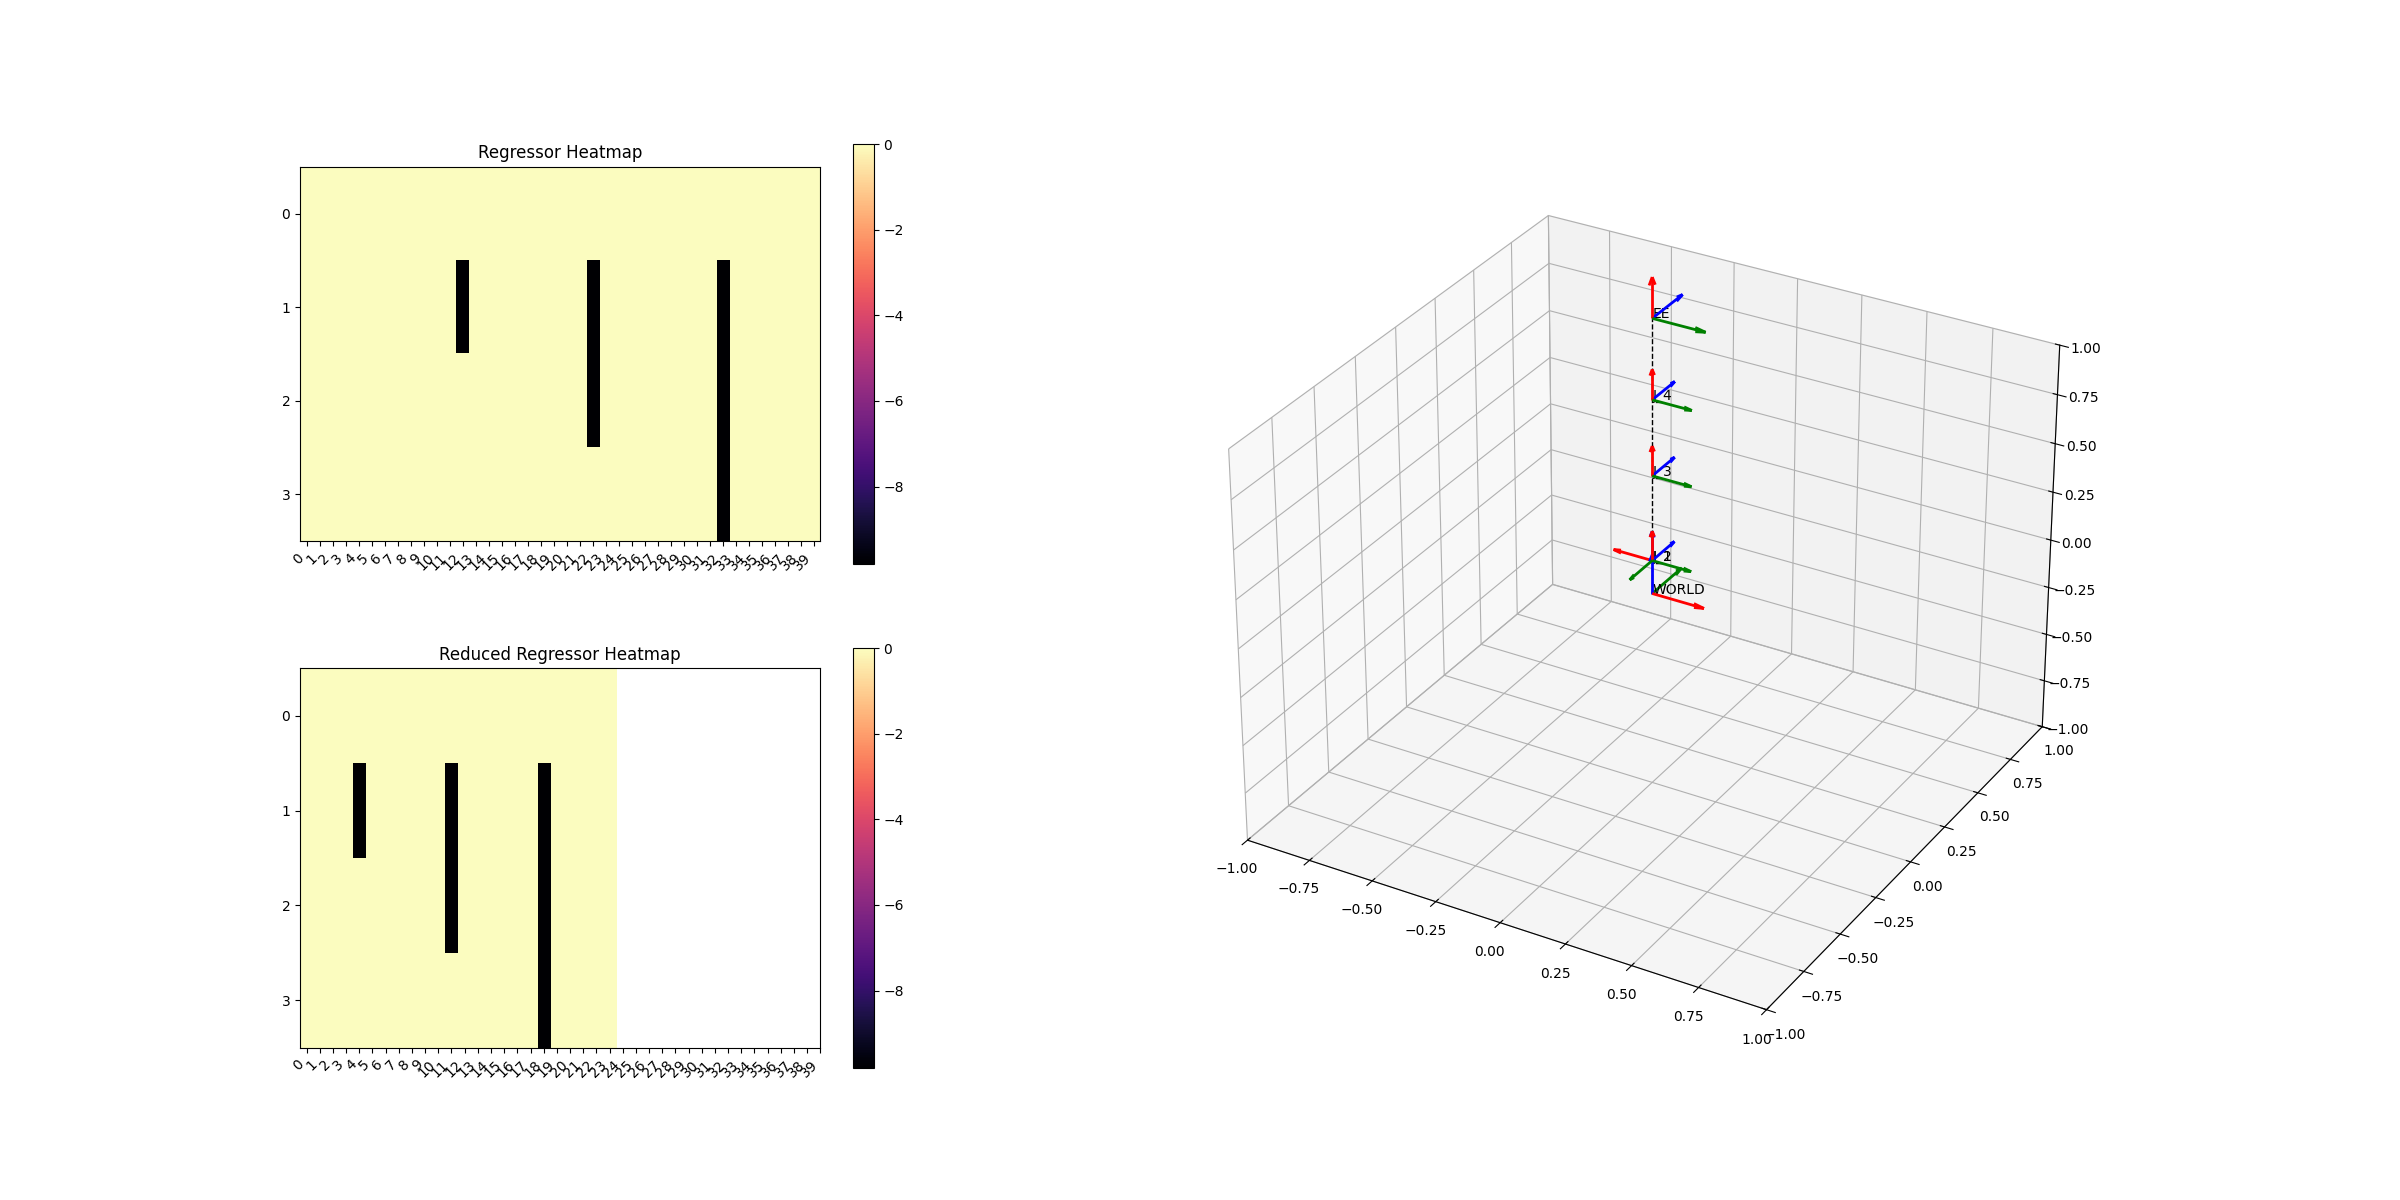

In [23]:
thunder_ahand = thunder_ahand_finger()
thunder_ahand.load_conf("/home/leo/thunder_dynamics/ahand_finger_generatedFiles/ahand_finger_conf.yaml")


# Sliders
q_sliders = [widgets.FloatSlider(value=0, min=-3.14, max=3.14, step=0.01, description=f'q{i}') for i in range(4)]
dq_sliders = [widgets.FloatSlider(value=0, min=-5, max=5, step=0.1, description=f'dq{i}') for i in range(4)]
ddq_sliders = [widgets.FloatSlider(value=0, min=-5, max=5, step=0.1, description=f'ddq{i}') for i in range(4)]

# Group sliders in boxes
q_box = widgets.VBox(q_sliders, layout=widgets.Layout(margin='0 0 10px 0'))
dq_box = widgets.VBox(dq_sliders, layout=widgets.Layout(margin='0 0 10px 0'))
ddq_box = widgets.VBox(ddq_sliders)

# Output widget
out = widgets.Output()


# Create figure and axes once
# --- Figure with two subplots: heatmap + 3D robot ---
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(24,12))
gs = GridSpec(2, 2, width_ratios=[1, 1.6])  # right side larger

# ----- TOP LEFT HEATMAP -----
ax_top = fig.add_subplot(gs[0, 0])
im_top = ax_top.imshow(np.zeros_like(thunder_ahand.get_Yr()),
                       cmap='magma', interpolation='nearest', aspect=0.6*12)
fig.colorbar(im_top, ax=ax_top)
ax_top.set_title('Regressor Heatmap')
ax_top.set_xticks(np.arange(40))
ax_top.set_yticks(np.arange(4))
plt.setp(ax_top.get_xticklabels(), rotation=45, ha='right')

# ----- BOTTOM LEFT HEATMAP -----
ax_bottom = fig.add_subplot(gs[1, 0])
im_bottom = ax_bottom.imshow(np.zeros_like(thunder_ahand.get_Yr() @ np.linalg.pinv(beta)),
                             cmap='magma', interpolation='nearest', aspect=0.6*12)
fig.colorbar(im_bottom, ax=ax_bottom)
ax_bottom.set_title('Reduced Regressor Heatmap')
ax_bottom.set_xticks(np.arange(40))
ax_bottom.set_yticks(np.arange(4))
plt.setp(ax_bottom.get_xticklabels(), rotation=45, ha='right')

# ----- LARGE RIGHT SIDE 3D PLOT -----
ax_3d = fig.add_subplot(gs[:, 1], projection='3d')  # span both rows
ax_3d.set_title('Robot Frames')


def plot_frame(T, ax, name=None, length=0.1):
    origin = T[:3, 3]
    x_axis = T[:3, 0] * length
    y_axis = T[:3, 1] * length
    z_axis = T[:3, 2] * length

    ax.quiver(*origin, *x_axis, color='r', linewidth=2, arrow_length_ratio=0.2)
    ax.quiver(*origin, *y_axis, color='g', linewidth=2, arrow_length_ratio=0.2)
    ax.quiver(*origin, *z_axis, color='b', linewidth=2, arrow_length_ratio=0.2)
    if name:
        ax.text(*origin, name, fontsize=10, color='k')


# Update function
def update(**kwargs):
    q = np.array([kwargs[f'q{i}'] for i in range(4)])
    dq = np.array([kwargs[f'dq{i}'] for i in range(4)])
    ddq = np.array([kwargs[f'ddq{i}'] for i in range(4)])

    thunder_ahand.set_q(q)
    thunder_ahand.set_dq(dq)
    thunder_ahand.set_dqr(dq)
    thunder_ahand.set_ddqr(ddq)
    # Compute regressor and reduced one
    Y = thunder_ahand.get_Yr()
    Y_hat = Y @ np.linalg.pinv(beta)

    # Compute transform
    frames = [np.eye(4)]  # Base frame
    for i in range(1, thunder_ahand.get_numJoints()+1):
        Ti = getattr(thunder_ahand, f"get_T_0_{i}")()  # Dynamically call robot.get_T_0_i()
        frames.append(Ti)
    frames.append(thunder_ahand.get_T_0_ee())  # End-Effecto frame

    # --- Update heatmap data ---
    im_top.set_data(Y)
    im_top.set_clim(vmin=Y.min(), vmax=Y.max())  # adjust color scale if needed
    im_bottom.set_data(Y_hat)
    im_bottom.set_clim(vmin=Y.min(), vmax=Y.max())  # adjust color scale if needed

    # --- Update 3D robot plot ---
    ax_3d.cla()  # Clear previous frames
    ax_3d.set_xlim(-1,1)
    ax_3d.set_ylim(-1,1)
    ax_3d.set_zlim(-1,1)
    for i, T in enumerate(frames):
        print(f"T_0_{i}:\n", T[:3, 3])
        if i == 0:
            plot_frame(T, ax_3d, 'WORLD', length=0.2)
        elif i == thunder_ahand.get_numJoints() + 1:
            plot_frame(T, ax_3d, 'EE', length=0.2)
        else:
            plot_frame(T, ax_3d, f'J_{i}', length=0.15)
    origins = np.array([T[:3, 3] for T in frames]) # Connect origins (optional, to show chain)
    ax_3d.plot(origins[:, 0], origins[:, 1], origins[:, 2], 'k--', linewidth=1)
    #for i, p in enumerate(origins):   # --- Add translation labels next to each point 
    #    label = f"({p[0]:.2f}, {p[1]:.2f}, {p[2]:.2f})"
    #    ax_3d.text(p[0], p[1], p[2] + 0.03, label, color='black', fontsize=9)
    
    fig.canvas.draw_idle()

# Combine sliders
all_sliders = {f'q{i}': s for i, s in enumerate(q_sliders)}
all_sliders.update({f'dq{i}': s for i, s in enumerate(dq_sliders)})
all_sliders.update({f'ddq{i}': s for i, s in enumerate(ddq_sliders)})

# Interactive widget
interactive_widget = widgets.interactive(update, **all_sliders)
display(widgets.HBox([q_box, dq_box, ddq_box]), out)

# Usage in Allegro Dynamic Estimation

## Estimation 

In [49]:
# =========================================================================================================================== Import
import time
import os
import shutil

%matplotlib ipympl
from matplotlib import pyplot as plt
from scipy.linalg import solve_continuous_lyapunov, block_diag

import rosbag2_py
from rclpy.serialization import serialize_message, deserialize_message
from sensor_msgs.msg import JointState
import casadi

import numpy as np
from tqdm import tqdm

import pandas as pd

from scipy.signal import butter, filtfilt, savgol_filter

MESH_DIR = './description/urdf/meshes/'
URDF_PATH = './description/urdf/allegro_hand_description_right_B.urdf'
XML_PATH = './description/urdf/allegro_hand_description_right_B.xml'
BAG_PATH = '/home/leo/Desktop/allegro_hand_ros2_ws/workdir/allegro_hand_test_traject_bag'
NEW_BAG_PATH = '/home/leo/Desktop/allegro_hand_ros2_ws/workdir/allegro_hand_torque_filtered_bag'
CSV_PATH = '/home/leo/Desktop/allegro_hand_ros2_ws/workdir/allegro_log.csv'
JOINT_NAMES = ['joint_4_0', 'joint_5_0', 'joint_6_0', 'joint_7_0']
SAVE_FILENAME = '/home/leo/Desktop/ahand_dynamic_friction.txt'

MASSES_URDF = [0.0176, 0.086, 0.0367, 0.0057] # [Kg]
INERTIAS_URDF = [[1.32064e-05, 1.22498e-05, 2.64678e-06],
                 [5.66968e-05, 4.87935e-05, 1.75097e-05],
                 [1.45504e-05, 1.30076e-05, 3.70193e-06],
                 [5.27679e-06, 4.04675e-06, 2.638e-06]] # [Kg m^2]

np.random.seed(41)


In [50]:
# =========================================================================================================================== Define Function
# Bag Read/Write
def read_bag(file_path, topic_name = '/allegroHand_0/joint_states', store=False, path_out=None):
    first = True
    # Open the bag reader
    reader = rosbag2_py.SequentialReader()

    # set options and open the bag
    storage_options = rosbag2_py.StorageOptions(uri=file_path)
    converter_options = rosbag2_py.ConverterOptions('', '')
    reader.open(storage_options, converter_options)

    dataset = []
    header = []
    # scroll the bag
    while reader.has_next():
        (topic, data, t) = reader.read_next()
        if topic == topic_name:
        #if topic == '/allegroHand_0/torque_cmd':
            msg = deserialize_message(data, JointState)
            joint_names = msg.name

            # select specific joints
            indices = [joint_names.index(name) for name in JOINT_NAMES if name in joint_names]
            selected_joint_names = [joint_names[i] for i in indices]
            if first:
                joint_names = msg.name
                # get header
                pos_header    = [f"pos_{name}" for name in selected_joint_names]
                effort_header = [f"eff_{name}" for name in selected_joint_names]
                vel_header    = [f"vel_{name}" for name in selected_joint_names]
                #acc_header    = [f"acc_{name}" for name in selected_joint_names]
                #header = ['t'] + pos_header + vel_header + acc_header + effort_header
                header = ['t'] + pos_header + effort_header + vel_header
                first = False
            elif joint_names != msg.name:
                raise ValueError("Joint names do not match")

            # Store data
            selected_positions = [msg.position[i] for i in indices]
            selected_velocities = [msg.velocity[i] for i in indices]
            selected_effort = [msg.effort[i] for i in indices]
            row = [t/1e9] + selected_positions + selected_effort + selected_velocities
            dataset.append(row)

    # store in dataframe
    df = pd.DataFrame(dataset, columns=header)
    if store:
        df.to_csv(file_path, index=False)

    return df
def read_csv(file_path, joint_names = None, store=False, path_out=None):
    # Read the CSV
    df_raw = pd.read_csv(file_path)

    # Infer joint names if not provided
    if joint_names is None:
        joint_names = sorted(set(
            c.replace('_pos', '').replace('_vel', '').replace('_effort', '')
            for c in df_raw.columns if any(x in c for x in ['_pos', '_vel', '_effort'])
        ))

    # Input column names (from CSV)
    pos_in = [f"{j}_pos" for j in joint_names]
    eff_in = [f"{j}_effort" for j in joint_names]
    vel_in = [f"{j}_vel" for j in joint_names]

    # Output column names (desired format)
    pos_out = [f"pos_{j}" for j in joint_names]
    eff_out = [f"eff_{j}" for j in joint_names]
    vel_out = [f"vel_{j}" for j in joint_names]

    # Build final DataFrame with renamed columns
    df = pd.DataFrame()
    df['t'] = range(len(df_raw))  # add time index
    for in_cols, out_cols in zip([pos_in, eff_in, vel_in], [pos_out, eff_out, vel_out]):
        for ci, co in zip(in_cols, out_cols):
            if ci in df_raw.columns:
                df[co] = df_raw[ci]
            else:
                df[co] = None  # if missing, fill with NaN

    # Optionally store
    if store:
        out_path = path_out or file_path.replace('.csv', '_parsed.csv')
        df.to_csv(out_path, index=False)

    return df

def write_filtered_bag(file_path, t_log, q_log, tau_log, joint_names_filtered):
    if os.path.exists(file_path):
        print(f"Overwriting existing bag: {file_path}")
        shutil.rmtree(file_path)
    all_joint_names = [f'joint_{i}_0' for i in range(15)]
    # Create writer
    writer = rosbag2_py.SequentialWriter()
    storage_options = rosbag2_py.StorageOptions(uri=file_path, storage_id='sqlite3')
    converter_options = rosbag2_py.ConverterOptions('', '')
    writer.open(storage_options, converter_options)

    # Create topic metadata
    topic_name = '/allegroHand_0/torque_cmd'
    topic_type = 'sensor_msgs/msg/JointState'
    writer.create_topic(rosbag2_py.TopicMetadata(name=topic_name,
                                                 type=topic_type,
                                                 serialization_format='cdr'))

    # Map filtered indices to full joint list
    idx_map = [all_joint_names.index(j) if j in all_joint_names else None for j in joint_names_filtered]

    # Write data
    for i in range(len(t_log)):
        msg = JointState()
        msg.header.stamp.sec = int(t_log[i])
        msg.header.stamp.nanosec = int((t_log[i] - int(t_log[i])) * 1e9)
        msg.name = all_joint_names
        # Initialize all zeros
        q_full = np.zeros(15)
        tau_full = np.zeros(15)
        # Fill available joints
        for j, idx in enumerate(idx_map):
            if idx is not None:
                q_full[idx] = q_log[i, j]
                tau_full[idx] = tau_log[i, j]

        msg.position = q_full.tolist()
        msg.effort = tau_full.tolist()
        writer.write(topic_name, serialize_message(msg), int(t_log[i]*1e9))

    print(f"Filtered bag written to {file_path} with all joints 0-14")


# Matrix Eigenvalues
def powerm(v, A, niter): #POWER ITERATION METHOD
    for i in range(niter):
        v = A @ v
        v = v/casadi.norm_2(v)
    l = v.T@A@v
    return v, l
def def_powerm(a, niter=None): #DEFLATION VERSION OF PIM FOR 3X3 MATRIX ---> CALCULATE ALL EIGENVALUES FROM GREATER TO SMALLER
    #AND THEIR EIGENVECTORS
    v0 = casadi.DM([1,1,1])

    if niter is None:
        niter = 40

    v1,l1 = powerm(v0, a, niter)

    v0 = casadi.DM([0,1,1])
    a2 = a - l1*(v1 @ v1.T)
    v2, l2 = powerm(v0, a2, niter)

    v0 = casadi.DM([0,0,1])
    a3 = a2 - l2 * (v2 @ v2.T)
    v3, l3 = powerm(v0, a3, niter)


    D = casadi.vertcat(l1,l2,l3)
    V = casadi.horzcat(v1,v2,v3)
    return V, D
sym_matrix = casadi.SX.sym('M', 3, 3)
eigenvalues = casadi.eig_symbolic(sym_matrix)
f_eigen = casadi.Function('eigen', [sym_matrix], [eigenvalues])
_, eigenvalues = def_powerm(sym_matrix)
f_powerm = casadi.Function('powerm', [sym_matrix], [eigenvalues])
#minimum eigenvalue
def minimum(eigen):
    min = 10000000000000
    for i in range(3):
        min = casadi.if_else(eigen[i] <= min, eigen[i], min)

    return min
def SN(eigen):
    p = 3
    l1 = eigen[0]**(-p)
    l2 = eigen[1]**(-p)
    l3 = eigen[2]**(-p)

    min = (l1 + l2 + l3)**(-1/p)


    return min
def det(A):
    if np.isscalar(A):
        return A
    elif A.shape[0]==1:
        return A[0,0]
    elif A.shape[0]==2:
        return (A[0,0]*A[1,1] - A[1,0]*A[0,1])
    elif A.shape[0]==3:
        return (A[0, 0]*(A[1, 1]*A[2, 2] - A[1, 2]*A[2, 1])
                - A[0, 1]*(A[1, 0]*A[2, 2] - A[1, 2]*A[2, 0])
                + A[0, 2]*(A[1, 0]*A[2, 1] - A[1, 1]*A[2, 0]))
    else:
        raise NotImplementedError("Supported dimensions: 1x1, 2x2, 3x3")
# Skew-symmetric matrix
def skew(v):
    return np.array([[0, -v[2], v[1]],
                     [v[2], 0, -v[0]],
                     [-v[1], v[0], 0]])
def casadi_skew(v):
    return casadi.vertcat(
        casadi.horzcat(0, -v[2], v[1]),
        casadi.horzcat(v[2], 0, -v[0]),
        casadi.horzcat(-v[1], v[0], 0)
    )

# Dynamic Parameters Store/Load
def save_dynamics(filename, hat_Pi, num_joints):
    par_per_link = int(hat_Pi.shape[0]/num_joints)

    masses = [(hat_Pi[i*par_per_link]).item() for i in range(num_joints)]

    CoMs_x = [(hat_Pi[i*par_per_link+1]/masses[i]).item() for i in range(num_joints)]        #pi = m*cx
    CoMs_y = [(hat_Pi[i*par_per_link+2]/masses[i]).item() for i in range(num_joints)]
    CoMs_z = [(hat_Pi[i*par_per_link+3]/masses[i]).item() for i in range(num_joints)]

    Is_xx = [(hat_Pi[i*par_per_link+4] - (masses[i]*CoMs_y[i]**2 - masses[i]*CoMs_z[i]**2)).item()      for i in range(num_joints)]
    Is_xy = [(hat_Pi[i*par_per_link+5] - (masses[i]*CoMs_x[i]*CoMs_y[i])).item()                        for i in range(num_joints)]
    Is_xz = [(hat_Pi[i*par_per_link+5] - (masses[i]*CoMs_x[i]*CoMs_z[i])).item()                        for i in range(num_joints)]
    Is_yy = [(hat_Pi[i*par_per_link+7] - (masses[i]*CoMs_x[i]**2 - masses[i]*CoMs_z[i]**2)).item()   for i in range(num_joints)]
    Is_yz = [(hat_Pi[i*par_per_link+8] - (masses[i]*CoMs_y[i]*CoMs_z[i])).item()   for i in range(num_joints)]
    Is_zz = [(hat_Pi[i*par_per_link+9] - (masses[i]*CoMs_x[i]**2 - masses[i]*CoMs_y[i]**2)).item()   for i in range(num_joints)]
    if par_per_link>10:
        Ds = [(hat_Pi[i*par_per_link+10]).item()        for i in range(n)]
        Fs = [(hat_Pi[i*par_per_link+11]).item()        for i in range(n)]

    with open(filename, 'w') as f:
        f.write("=== Dynamic parameters ======\n")
        f.write(f"PI size: {hat_Pi.shape}\n")
        for i in range(num_joints):
            f.write(f"\tlink {i+1}:\n")
            f.write(f"\t\tinertial:\n")
            f.write(f"\t\t\tsymb: [1,1,1,1,1,1,1,1,1,1]\n")
            f.write(f"\t\t\tmass: {masses[i]}\n")
            f.write(f"\t\t\tCoM_x: {CoMs_x[i]}\n")
            f.write(f"\t\t\tCoM_y: {CoMs_y[i]}\n")
            f.write(f"\t\t\tCoM_z: {CoMs_z[i]}\n")
            f.write(f"\t\t\tIxx: {Is_xx[i]}\n")
            f.write(f"\t\t\tIxy: {Is_xy[i]}\n")
            f.write(f"\t\t\tIxz: {Is_xz[i]}\n")
            f.write(f"\t\t\tIyy: {Is_yy[i]}\n")
            f.write(f"\t\t\tIyz: {Is_yz[i]}\n")
            f.write(f"\t\t\tIzz: {Is_zz[i]}\n")
            if par_per_link>10:
                f.write(f"\t\tfriction:\n")
                f.write(f"\t\t\tsymb: [1,1]\n")
                f.write(f"\t\t\tDl: [{Ds[i]},{Fs[i]}]\n")
        f.write("=============================\n")
def load_dynamics(filename, num_joints): # filename -> (hat_Pi, dict)
    dynamics = {}
    hat_Pi = np.zeros(12*num_joints)
    with open(filename, 'r') as f:
        lines = f.readlines()

    for line in lines:
        line = line.strip()
        if line.startswith('mass:'):
            dynamics.setdefault('mass', []).append(float(line.split(':')[1]))
        elif line.startswith('CoM_x:'):
            dynamics.setdefault('CoM_x', []).append(float(line.split(':')[1]))
        elif line.startswith('CoM_y:'):
            dynamics.setdefault('CoM_y', []).append(float(line.split(':')[1]))
        elif line.startswith('CoM_z:'):
            dynamics.setdefault('CoM_z', []).append(float(line.split(':')[1]))
        elif line.startswith('Ixx:'):
            dynamics.setdefault('Ixx', []).append(float(line.split(':')[1]))
        elif line.startswith('Ixy:'):
            dynamics.setdefault('Ixy', []).append(float(line.split(':')[1]))
        elif line.startswith('Ixz:'):
            dynamics.setdefault('Ixz', []).append(float(line.split(':')[1]))
        elif line.startswith('Iyy:'):
            dynamics.setdefault('Iyy', []).append(float(line.split(':')[1]))
        elif line.startswith('Iyz:'):
            dynamics.setdefault('Iyz', []).append(float(line.split(':')[1]))
        elif line.startswith('Izz:'):
            dynamics.setdefault('Izz', []).append(float(line.split(':')[1]))

    # reconstruct hat_Pi
    hat_Pi[0::12] = dynamics['mass']
    hat_Pi[1::12] = dynamics['CoM_x'] * dynamics['mass']
    hat_Pi[2::12] = dynamics['CoM_y'] * dynamics['mass']
    hat_Pi[3::12] = dynamics['CoM_z'] * dynamics['mass']
    hat_Pi[4::12] = dynamics['Ixx'] + dynamics['mass'] * (dynamics['CoM_y']**2 + dynamics['CoM_z']**2)
    hat_Pi[5::12] = dynamics['Ixy'] + dynamics['mass'] * (dynamics['CoM_x'] * dynamics['CoM_y'])
    hat_Pi[6::12] = dynamics['Ixz'] + dynamics['mass'] * (dynamics['CoM_x'] * dynamics['CoM_z'])
    hat_Pi[7::12] = dynamics['Iyy'] + dynamics['mass'] * (dynamics['CoM_x']**2 + dynamics['CoM_z']**2)
    hat_Pi[8::12] = dynamics['Iyz'] + dynamics['mass'] * (dynamics['CoM_y'] * dynamics['CoM_z'])
    hat_Pi[9::12] = dynamics['Izz'] + dynamics['mass'] * (dynamics['CoM_x']**2 + dynamics['CoM_y']**2)


    return hat_Pi, dynamics

def print_result(hat_Pi, par_per_link):
    masses = [(hat_Pi[i*par_per_link]).item() for i in range(n)]

    CoMs_x = [(hat_Pi[i*par_per_link+1]/masses[i]).item() for i in range(n)]        #pi = m*cx
    CoMs_y = [(hat_Pi[i*par_per_link+2]/masses[i]).item() for i in range(n)]
    CoMs_z = [(hat_Pi[i*par_per_link+3]/masses[i]).item() for i in range(n)]

    Is_xx = [(hat_Pi[i*par_per_link+4] - (masses[i]*CoMs_y[i]**2 - masses[i]*CoMs_z[i]**2)).item()        for i in range(n)]
    Is_xy = [(hat_Pi[i*par_per_link+5] - (masses[i]*CoMs_x[i]*CoMs_y[i])).item()                          for i in range(n)]
    Is_xz = [(hat_Pi[i*par_per_link+5] - (masses[i]*CoMs_x[i]*CoMs_z[i])).item()                          for i in range(n)]
    Is_yy = [(hat_Pi[i*par_per_link+7] - (masses[i]*CoMs_x[i]**2 - masses[i]*CoMs_z[i]**2)).item()        for i in range(n)]
    Is_yz = [(hat_Pi[i*par_per_link+8] - (masses[i]*CoMs_y[i]*CoMs_z[i])).item()                          for i in range(n)]
    Is_zz = [(hat_Pi[i*par_per_link+9] - (masses[i]*CoMs_x[i]**2 - masses[i]*CoMs_y[i]**2)).item()        for i in range(n)]

    if par_per_link>10:
        Ds = [(hat_Pi[i*par_per_link+10]).item()        for i in range(n)]
        Fs = [(hat_Pi[i*par_per_link+11]).item()        for i in range(n)]
    print("=== Dynamic parameters ======")
    print("PI size:", hat_Pi.shape)
    for i in range(thunder_ahand.get_numJoints()):
        print(f"\tlink {i+1}:")
        print(f"\t\tinertial:")
        print(f"\t\t\tsymb: [1,1,1,1,1,1,1,1,1,1]")
        print(f"\t\t\tmass: {masses[i]}")
        print(f"\t\t\tCoM_x: {CoMs_x[i]}")
        print(f"\t\t\tCoM_y: {CoMs_y[i]}")
        print(f"\t\t\tCoM_z: {CoMs_z[i]}")
        print(f"\t\t\tIxx: {Is_xx[i]}")
        print(f"\t\t\tIxy: {Is_xy[i]}")
        print(f"\t\t\tIxz: {Is_xz[i]}")
        print(f"\t\t\tIyy: {Is_yy[i]}")
        print(f"\t\t\tIyz: {Is_yz[i]}")
        print(f"\t\t\tIzz: {Is_zz[i]}")
        if par_per_link>10:
            print(f"\t\tfriction: ")
            print(f"\t\t\tsymb: [1,1]")
            print(f"\t\t\tDl: [{Ds[i]},{Fs[i]}]")
    print("=============================")

In [51]:
# =========================================================================================================================== Process data
INTERVAL = [20, 10000]
df = read_bag(BAG_PATH, topic_name='/allegroHand_0/joint_states', store=False)


t0 = df['t'].to_numpy()[0]
df = df[(df['t'] - t0 >= INTERVAL[0]) & (df['t'] - t0 <= INTERVAL[1])]
t_log = df['t'].to_numpy() - t0
q_log = df[[col for col in df.columns if col.startswith('pos_')]].to_numpy()
qd_log = df[[col for col in df.columns if col.startswith('vel_')]].to_numpy()
tau_log = df[[col for col in df.columns if col.startswith('eff_')]].to_numpy()

Dt = np.mean(np.diff(t_log))    # sampling period
F_s = 1.0 / Dt                  # sampling frequency
t_ori = t_log.copy()            # store original data
q_ori = q_log.copy()
qd_ori = qd_log.copy()
tau_ori = tau_log.copy()


"""
df2 = df2[(df2['t'] - t0 >= INTERVAL[0]) & (df2['t'] - t0 <= INTERVAL[1])]
t_log2 = df2['t'].to_numpy() - t0
q_log2 = df2[[col for col in df2.columns if col.startswith('pos_')]].to_numpy()
qd_log2 = df2[[col for col in df2.columns if col.startswith('vel_')]].to_numpy()
tau_log2 = df2[[col for col in df2.columns if col.startswith('eff_')]].to_numpy()
t_ori2 = t_log2.copy()            # store original data
q_ori2 = q_log2.copy()
qd_ori2 = qd_log2.copy()
tau_ori2 = tau_log2.copy()
"""
# 1. Filtering position
""" Savitzy-golay
# Parameters
window_length = 41   # must be odd, ~ window of ~50 ms if fs=1000Hz
polyorder = 3        # polynomial order (2–4 typical)
# Filter position
q_filt = savgol_filter(q_log, window_length=window_length, polyorder=polyorder, axis=0)
# First derivative → velocity
qd_log = savgol_filter(q_log, window_length=window_length, polyorder=polyorder, deriv=1, delta=dt, axis=0)
# Second derivative → acceleration
qdd_log = savgol_filter(q_log, window_length=window_length, polyorder=polyorder, deriv=2, delta=dt, axis=0)
# store filtered joint position
q_ori = q_log
q_log = q_filt
"""

""" ------------------------------------------------------------------ moving average filter + finite difference
window_size = 50
# 1. filter position
q_filt = np.convolve(q_log[:,0], np.ones(window_size)/window_size, mode='same').reshape(-1,1)
for i in range(1,q_log.shape[1]):
    # filtering each joint separately
    q_filt_i = np.convolve(q_log[:,i], np.ones(window_size)/window_size, mode='same').reshape(-1,1)
    q_filt = np.hstack((q_filt, q_filt_i))

# discard edges
edge = window_size // 2
q_log = q_filt[edge:-edge,:]
t_log = t_log[edge:-edge]

# 2. First derivative → velocity
qd = np.gradient(q_log, dt, axis=0)
t_vel = t_log.copy()
# filter velocity
qd_filt = np.convolve(qd[:,0], np.ones(window_size)/window_size, mode='same').reshape(-1,1)
for i in range(1, qd.shape[1]):
    # filtering each joint separately
    qd_filt_i = np.convolve(qd[:,i], np.ones(window_size)/window_size, mode='same').reshape(-1,1)
    qd_filt =  np.hstack((qd_filt, qd_filt_i))
# discard edges
t_log = t_log[edge:-edge]
q_log = q_log[edge:-edge,:]
qd_log = qd_filt[edge:-edge,:]

# 3. Second derivative → acceleration
qdd = np.gradient(qd_log, dt, axis=0)
t_acc = t_log.copy()
# filter accedeleration
qdd_filt = np.convolve(qdd[:,0], np.ones(window_size)/window_size, mode='same').reshape(-1,1)
for i in range(1,qd.shape[1]):
    # filtering each joint separately
    qdd_filt_i = np.convolve(qdd[:,i], np.ones(window_size)/window_size, mode='same').reshape(-1,1)
    qdd_filt =  np.hstack((qdd_filt, qdd_filt_i))
# discard edges
t_log = t_log[edge:-edge]
q_log = q_log[edge:-edge,:]
qd_log = qd_log[edge:-edge,:]
qdd_log = qdd_filt[edge:-edge,:]"""

""" ------------------------------------------------------------------  Kalman Filtering
class KalmanFilter():
    def __init__(self, sigma_u, sigma_r):
        # state
        self.hat_x = np.zeros((3, 1)) # x = {q, dq, ddq} [rad, rad/s, rad/s^2]
        #self.Pk = 1e-7*np.eye(3,3)
        self.Pk = np.array([[7.43901056e-08, 2.43974556e-05, 4.00077293e-03],
                            [2.43974556e-05, 1.59072400e-02, 3.90492122e+00],
                            [4.00077293e-03, 3.90492122e+00, 1.28068298e+03]])
        # dynamics
        self.Ak = np.array([[0, 1, 0],
                            [0, 0, 1],
                            [0, 0, 0]])
        self.A2k = np.array([[0, 0, 1],
                             [0, 0, 0],
                             [0, 0, 0]])
        self.Hk = np.array([[1, 0, 0]])
        # Kalman values
        self.sigma_u = sigma_u # process noise
        self.Rk = sigma_r * np.eye(1)  # measurement noise

    def prediction(self, dt):
        I = np.eye(3)
        Fd = I + dt*self.Ak + dt*dt/2*self.A2k # discrete transiction
        self.hat_x = Fd @ self.hat_x

        G = np.array([[1/2*dt*dt],
                      [dt],
                      [1]])

        Qk = (self.sigma_u*self.sigma_u)*(G @ G.T)

        self.Pk = Fd @ self.Pk @ Fd.T + Qk

    def update(self, z):
        I = np.eye(3)
        yk = z - self.Hk @ self.hat_x
        Sk = self.Hk @ self.Pk @ self.Hk.T + self.Rk
        Kk = self.Pk @ self.Hk.T @ np.linalg.inv(Sk)
        self.hat_x = self.hat_x + Kk @ yk

        self.Pk = (I - Kk @ self.Hk) @ self.Pk @ (I - Kk @ self.Hk).T + Kk @ self.Rk @ Kk.T

    def get_q(self):
        return self.hat_x[0]
    def get_qd(self):
        return self.hat_x[1]
    def get_qdd(self):
        return self.hat_x[2]

KFs = []
for i in range(4):
    KFs.append(KalmanFilter(1, 1e-7))

q_kf_filt = []
qd_kf_filt = []
qdd_kf_filt = []
q_tmp = []
qd_tmp = []
qdd_tmp = []

for i in range(len(t_log)):
#for i in range(5):
    for j in range(4):
        try:
            dt = t_log[i+1] - t_log[i]
        except:
            ft = t_log[i] - t_log[i-1]
        if i == 0:
            KFs[j].hat_x[0] = q_log[i][j]
        KFs[j].prediction(0.002)
        KFs[j].update(q_log[i][j])

        q_tmp.append(KFs[j].get_q())
        qd_tmp.append(KFs[j].get_qd())
        qdd_tmp.append(KFs[j].get_qdd())

    q_filt.append(np.array(q_tmp))
    qd_filt.append(np.array(qd_tmp))
    qdd_filt.append(np.array(qdd_tmp))
    q_tmp = []
    qd_tmp = []
    qdd_tmp = []

q_filt = np.array(q_filt)
qd_filt = np.array(qd_filt)
qdd_filt = np.array(qdd_filt)
"""

""" ------------------------------------------------------------------ Butterworth filter + centered finite difference 
"""
# Design Butterworth filter
order = 4
cutoff_freq = 30/(2*np.pi)  #[Hz] Note. Should be  1.6-6.4 Hz or 10-40 rad/s 
b, a = butter(order, cutoff_freq / (0.5 * F_s), btype='low')
# 1. Filter position
q_filt = filtfilt(b, a, q_log, axis=0)
q_log = q_filt
# 2. First derivative → velocity
dt_centered = t_log[2:] - t_log[:-2]
qd_filt = np.zeros_like(q_log)
qd_filt[1:-1,:] = (q_log[2:,:] - q_log[:-2,:])/(2*dt_centered[:,None])
qd_log = qd_filt
# 3. Second derivative → acceleration
qdd_filt = np.zeros_like(qd_log)
qdd_filt[1:-1,:] = (qd_log[2:,:] - qd_log[:-2,:])/(2*dt_centered[:,None])
qdd_log = qdd_filt
# 4. commanded torque
tau_filt = filtfilt(b, a, tau_log, axis=0)
tau_log = tau_filt


[INFO] [1763549020.067178203] [rosbag2_storage]: Opened database '/home/leo/Desktop/allegro_hand_ros2_ws/workdir/allegro_hand_test_traject_bag/allegro_hand_test_traject_bag_0.db3' for READ_ONLY.


In [ ]:
# =========================================================================================================================== Compute regressor
ahand_finger = thunder_ahand_finger()
ahand_finger.load_conf("/home/leo/thunder_dynamics/ahand_finger_generatedFiles/ahand_finger_conf.yaml")
_,beta =regrouping(DH)

# M(q) ddq + C(q,dq) dq + G(q) + D dq + F sign(dq) = Y(q,dq,ddq) pi = tau
#
# Regressor
#                  |                 |   | __Pi__ |  <- 40
# Y_tot . Pi_tot = |  Y  |  Yd  | Ys | . | _Pi_d_ |  <- 4
#                  |                 |   | _Pi_s_ |  <- 4
#                   ^4x40 ^4x4   ^4x4

Y_log = []
for i in range(t_log.shape[0]):
    #q =q_log[i,:]
    #dq = qd_log[i,:]
    #ddq = qdd_log[i,:]
    q =q_filt[i,:]
    dq = qd_filt[i,:]
    ddq = qdd_filt[i,:]

    ahand_finger.set_q(q)
    ahand_finger.set_dq(dq)
    ahand_finger.set_dqr(dq)
    ahand_finger.set_ddqr(ddq)
    Y = ahand_finger.get_Yr()
    Y_hat = Y @ np.linalg.pinv(beta)
    #Y_log.append(Y)
    # friction damping and static
    Y_d = np.diag(qd_log[i])
    Y_s = np.diag(2/(1+np.exp(-20*qd_log[i])) - 1)
    Y_log.append(np.hstack([Y_hat, Y_d, Y_s]))


print("> Computing Dynamics param")
M = len(t_log)
n = ahand_finger.get_numJoints()
print("Number of samples (M): ", M)
YY = np.concatenate([np.asarray(Y) for Y in Y_log], axis=0)
TTau = np.concatenate([np.asarray(t).reshape(n, 1) for t in tau_log], axis=0)

p = Y_log[0].shape[1]
par_per_link = int(p/n)
print("Shape YY (Mnxp): ", YY.shape)
print("Shape TTau (Mnx1): ", TTau.shape)


# Method 1 - Pinv
print("Computing initial guess by pseudoinverse")
print("\t Computing initial guess by pseudoinverse")
hat_Pi = np.linalg.pinv(YY)@TTau
print(np.array2string(hat_Pi.transpose()))
print("\t Residuals (Nm):" )
print(np.linalg.norm(TTau - YY @ hat_Pi))

r1 =  0
r2 =  1
Deleting I_yy, mc_z, m of link 3...
Deleting I_yy, mc_z, m of link 2...
Deleting I_yy, mc_z, m of link 1...
Deleting I_yy, mc_z, m of link 0...
Deleting I_xx, I_xy, I_xz, I_yz of link 0...
Regrouping completed in 1.1019706726074219 ms. Parameters reduced from 40 to  24
> Computing Dynamics param
Number of samples (M):  120923
Shape YY (Mnxp):  (483692, 32)
Shape TTau (Mnx1):  (483692, 1)
Computing initial guess by pseudoinverse
	 Computing initial guess by pseudoinverse
[[ 0.00000000e+00 -1.84109933e-17  1.59326637e-03  1.09745939e-02
  -8.95398371e-03  1.58570627e-04  1.55320484e-05 -4.79214962e-06
  -5.08305599e-05  2.02466181e-04  1.28551012e-03 -4.41112337e-04
  -1.52168438e-03  1.00358691e-04 -1.62571339e-04  9.06762313e-05
  -5.56410665e-04  1.00073143e-04 -1.75410844e-04  4.08598593e-04
  -4.62845316e-04  4.21863609e-05 -9.67447532e-05  5.54620982e-05
  -2.74246014e-02  1.39476119e-02  2.38435021e-03  5.58586592e-03
   1.10124252e-02  2.11060829e-02  6.21137556e-

In [ ]:
# Save beta matrix to file
ESTIM_FILENAME = "./ahand_finger_beta.h"

if not os.path.exists(ESTIM_FILENAME):
    beta_pinv = np.linalg.pinv(beta)
    print("Creating sparse beta and pi_hat C++ header file...")
    with open(ESTIM_FILENAME, "w") as f:
        f.write("// Auto-generated sparse beta and pi_hat\n")#include "beta_sparse.h"
        f.write("/* Usage\n")
        f.write('#include "ahand_finger_beta.h"\n\n')
        f.write("int main() {\n")
        f.write("    Eigen::SparseMatrix<double> beta;\n")
        f.write("    load_beta(beta);\n")
        f.write("\n")
        f.write("    auto pi_hat = load_pi_hat();\n")
        f.write("\n")
        f.write("    // Example usage:\n")
        f.write("    Eigen::VectorXd tau = Y * beta.pinv() * pi_hat;\n")
        f.write("\n")
        f.write('    std::cout << "tau = \n" << tau << std::endl;\n')
        f.write("}\n")
        f.write("*/\n\n")

        f.write("#include <Eigen/Dense>\n")
        f.write("#include <Eigen/Sparse>\n")
        f.write("#include <vector>\n\n")


        # Beta as sparse matrix---
        N, M = beta.shape
        # Triplets
        f.write("inline void load_beta(Eigen::SparseMatrix<double>& beta) {\n")
        f.write(f"    beta.resize({N}, {M});\n")
        f.write("    std::vector<Eigen::Triplet<double>> triplets;\n")
        f.write(f"    triplets.reserve({np.count_nonzero(beta)});\n\n")

        rows, cols = np.nonzero(beta)
        for r, c in zip(rows, cols):
            f.write(f"    triplets.emplace_back({r}, {c}, {beta[r,c]:.16g});\n")

        f.write("\n    beta.setFromTriplets(triplets.begin(), triplets.end());\n")
        f.write("}\n\n")

        # Beta Pseudo-Inverse as sparse matrix---
        N, M = beta_pinv.shape
        # Triplets
        f.write("inline void load_beta_pinv(Eigen::SparseMatrix<double>& beta_pinv) {\n")
        f.write(f"    beta_pinv.resize({N}, {M});\n")
        f.write( "    std::vector<Eigen::Triplet<double>> triplets;\n")
        f.write(f"    triplets.reserve({np.count_nonzero(beta_pinv)});\n\n")

        rows, cols = np.nonzero(beta_pinv)
        for r, c in zip(rows, cols):
            f.write(f"    triplets.emplace_back({r}, {c}, {beta_pinv[r,c]:.16g});\n")

        f.write("\n    beta_pinv.setFromTriplets(triplets.begin(), triplets.end());\n")
        f.write("}\n\n")

        # pi_hat as dense vector----
        f.write(f"inline Eigen::Matrix<double, {hat_Pi.shape[0]}, 1> load_pi_hat() {{\n")
        f.write(f"    Eigen::Matrix<double, {hat_Pi.shape[0]}, 1> v;\n")
        f.write("    v << \n")
        for i in range(hat_Pi.shape[0]):
            sep = "," if i < hat_Pi.shape[0]-1 else ";"
            f.write(f"        {hat_Pi[i,0]:.16g}{sep}\n")
        f.write("    return v;\n}\n")
    print(f"{ESTIM_FILENAME} created successfully.")
else:
    print(f"{ESTIM_FILENAME} already exists, skipping creation.")

Creating sparse beta and pi_hat C++ header file...
./ahand_finger_beta.h created successfully.


# Validation

In [53]:
# =========================================================================================================================== Process data
INTERVAL = [100, 200]


df = read_bag(BAG_PATH, topic_name='/allegroHand_0/joint_states', store=False)


t0 = df['t'].to_numpy()[0]
df = df[(df['t'] - t0 >= INTERVAL[0]) & (df['t'] - t0 <= INTERVAL[1]) & (df['t'] - t0 <= INTERVAL[1])]
t_log = df['t'].to_numpy() - t0
q_log = df[[col for col in df.columns if col.startswith('pos_')]].to_numpy()
qd_log = df[[col for col in df.columns if col.startswith('vel_')]].to_numpy()
tau_log = df[[col for col in df.columns if col.startswith('eff_')]].to_numpy()

Dt = np.mean(np.diff(t_log))    # sampling period
F_s = 1.0 / Dt                  # sampling frequency
t_ori = t_log.copy()            # store original data
q_ori = q_log.copy()
qd_ori = qd_log.copy()
tau_ori = tau_log.copy()


"""
df2 = df2[(df2['t'] - t0 >= INTERVAL[0]) & (df2['t'] - t0 <= INTERVAL[1])]
t_log2 = df2['t'].to_numpy() - t0
q_log2 = df2[[col for col in df2.columns if col.startswith('pos_')]].to_numpy()
qd_log2 = df2[[col for col in df2.columns if col.startswith('vel_')]].to_numpy()
tau_log2 = df2[[col for col in df2.columns if col.startswith('eff_')]].to_numpy()
t_ori2 = t_log2.copy()            # store original data
q_ori2 = q_log2.copy()
qd_ori2 = qd_log2.copy()
tau_ori2 = tau_log2.copy()
"""
# 1. Filtering position
""" Savitzy-golay
# Parameters
window_length = 41   # must be odd, ~ window of ~50 ms if fs=1000Hz
polyorder = 3        # polynomial order (2–4 typical)
# Filter position
q_filt = savgol_filter(q_log, window_length=window_length, polyorder=polyorder, axis=0)
# First derivative → velocity
qd_log = savgol_filter(q_log, window_length=window_length, polyorder=polyorder, deriv=1, delta=dt, axis=0)
# Second derivative → acceleration
qdd_log = savgol_filter(q_log, window_length=window_length, polyorder=polyorder, deriv=2, delta=dt, axis=0)
# store filtered joint position
q_ori = q_log
q_log = q_filt
"""

""" ------------------------------------------------------------------ moving average filter + finite difference
window_size = 50
# 1. filter position
q_filt = np.convolve(q_log[:,0], np.ones(window_size)/window_size, mode='same').reshape(-1,1)
for i in range(1,q_log.shape[1]):
    # filtering each joint separately
    q_filt_i = np.convolve(q_log[:,i], np.ones(window_size)/window_size, mode='same').reshape(-1,1)
    q_filt = np.hstack((q_filt, q_filt_i))

# discard edges
edge = window_size // 2
q_log = q_filt[edge:-edge,:]
t_log = t_log[edge:-edge]

# 2. First derivative → velocity
qd = np.gradient(q_log, dt, axis=0)
t_vel = t_log.copy()
# filter velocity
qd_filt = np.convolve(qd[:,0], np.ones(window_size)/window_size, mode='same').reshape(-1,1)
for i in range(1, qd.shape[1]):
    # filtering each joint separately
    qd_filt_i = np.convolve(qd[:,i], np.ones(window_size)/window_size, mode='same').reshape(-1,1)
    qd_filt =  np.hstack((qd_filt, qd_filt_i))
# discard edges
t_log = t_log[edge:-edge]
q_log = q_log[edge:-edge,:]
qd_log = qd_filt[edge:-edge,:]

# 3. Second derivative → acceleration
qdd = np.gradient(qd_log, dt, axis=0)
t_acc = t_log.copy()
# filter accedeleration
qdd_filt = np.convolve(qdd[:,0], np.ones(window_size)/window_size, mode='same').reshape(-1,1)
for i in range(1,qd.shape[1]):
    # filtering each joint separately
    qdd_filt_i = np.convolve(qdd[:,i], np.ones(window_size)/window_size, mode='same').reshape(-1,1)
    qdd_filt =  np.hstack((qdd_filt, qdd_filt_i))
# discard edges
t_log = t_log[edge:-edge]
q_log = q_log[edge:-edge,:]
qd_log = qd_log[edge:-edge,:]
qdd_log = qdd_filt[edge:-edge,:]"""

""" ------------------------------------------------------------------  Kalman Filtering
class KalmanFilter():
    def __init__(self, sigma_u, sigma_r):
        # state
        self.hat_x = np.zeros((3, 1)) # x = {q, dq, ddq} [rad, rad/s, rad/s^2]
        #self.Pk = 1e-7*np.eye(3,3)
        self.Pk = np.array([[7.43901056e-08, 2.43974556e-05, 4.00077293e-03],
                            [2.43974556e-05, 1.59072400e-02, 3.90492122e+00],
                            [4.00077293e-03, 3.90492122e+00, 1.28068298e+03]])
        # dynamics
        self.Ak = np.array([[0, 1, 0],
                            [0, 0, 1],
                            [0, 0, 0]])
        self.A2k = np.array([[0, 0, 1],
                             [0, 0, 0],
                             [0, 0, 0]])
        self.Hk = np.array([[1, 0, 0]])
        # Kalman values
        self.sigma_u = sigma_u # process noise
        self.Rk = sigma_r * np.eye(1)  # measurement noise

    def prediction(self, dt):
        I = np.eye(3)
        Fd = I + dt*self.Ak + dt*dt/2*self.A2k # discrete transiction
        self.hat_x = Fd @ self.hat_x

        G = np.array([[1/2*dt*dt],
                      [dt],
                      [1]])

        Qk = (self.sigma_u*self.sigma_u)*(G @ G.T)

        self.Pk = Fd @ self.Pk @ Fd.T + Qk

    def update(self, z):
        I = np.eye(3)
        yk = z - self.Hk @ self.hat_x
        Sk = self.Hk @ self.Pk @ self.Hk.T + self.Rk
        Kk = self.Pk @ self.Hk.T @ np.linalg.inv(Sk)
        self.hat_x = self.hat_x + Kk @ yk

        self.Pk = (I - Kk @ self.Hk) @ self.Pk @ (I - Kk @ self.Hk).T + Kk @ self.Rk @ Kk.T

    def get_q(self):
        return self.hat_x[0]
    def get_qd(self):
        return self.hat_x[1]
    def get_qdd(self):
        return self.hat_x[2]

KFs = []
for i in range(4):
    KFs.append(KalmanFilter(1, 1e-7))

q_kf_filt = []
qd_kf_filt = []
qdd_kf_filt = []
q_tmp = []
qd_tmp = []
qdd_tmp = []

for i in range(len(t_log)):
#for i in range(5):
    for j in range(4):
        try:
            dt = t_log[i+1] - t_log[i]
        except:
            ft = t_log[i] - t_log[i-1]
        if i == 0:
            KFs[j].hat_x[0] = q_log[i][j]
        KFs[j].prediction(0.002)
        KFs[j].update(q_log[i][j])

        q_tmp.append(KFs[j].get_q())
        qd_tmp.append(KFs[j].get_qd())
        qdd_tmp.append(KFs[j].get_qdd())

    q_filt.append(np.array(q_tmp))
    qd_filt.append(np.array(qd_tmp))
    qdd_filt.append(np.array(qdd_tmp))
    q_tmp = []
    qd_tmp = []
    qdd_tmp = []

q_filt = np.array(q_filt)
qd_filt = np.array(qd_filt)
qdd_filt = np.array(qdd_filt)
"""

""" ------------------------------------------------------------------ Butterworth filter + centered finite difference 
"""
# Design Butterworth filter
order = 4
cutoff_freq = 30/(2*np.pi)  #[Hz] Note. Should be  1.6-6.4 Hz or 10-40 rad/s 
b, a = butter(order, cutoff_freq / (0.5 * F_s), btype='low')
# 1. Filter position
q_filt = filtfilt(b, a, q_log, axis=0)
q_log = q_filt
# 2. First derivative → velocity
dt_centered = t_log[2:] - t_log[:-2]
qd_filt = np.zeros_like(q_log)
qd_filt[1:-1,:] = (q_log[2:,:] - q_log[:-2,:])/(2*dt_centered[:,None])
qd_log = qd_filt
# 3. Second derivative → acceleration
qdd_filt = np.zeros_like(qd_log)
qdd_filt[1:-1,:] = (qd_log[2:,:] - qd_log[:-2,:])/(2*dt_centered[:,None])
qdd_log = qdd_filt
# 4. commanded torque
tau_filt = filtfilt(b, a, tau_log, axis=0)
tau_log = tau_filt


[INFO] [1763549046.951063483] [rosbag2_storage]: Opened database '/home/leo/Desktop/allegro_hand_ros2_ws/workdir/allegro_hand_test_traject_bag/allegro_hand_test_traject_bag_0.db3' for READ_ONLY.


Residuals: 0.02892305357660377 Nm


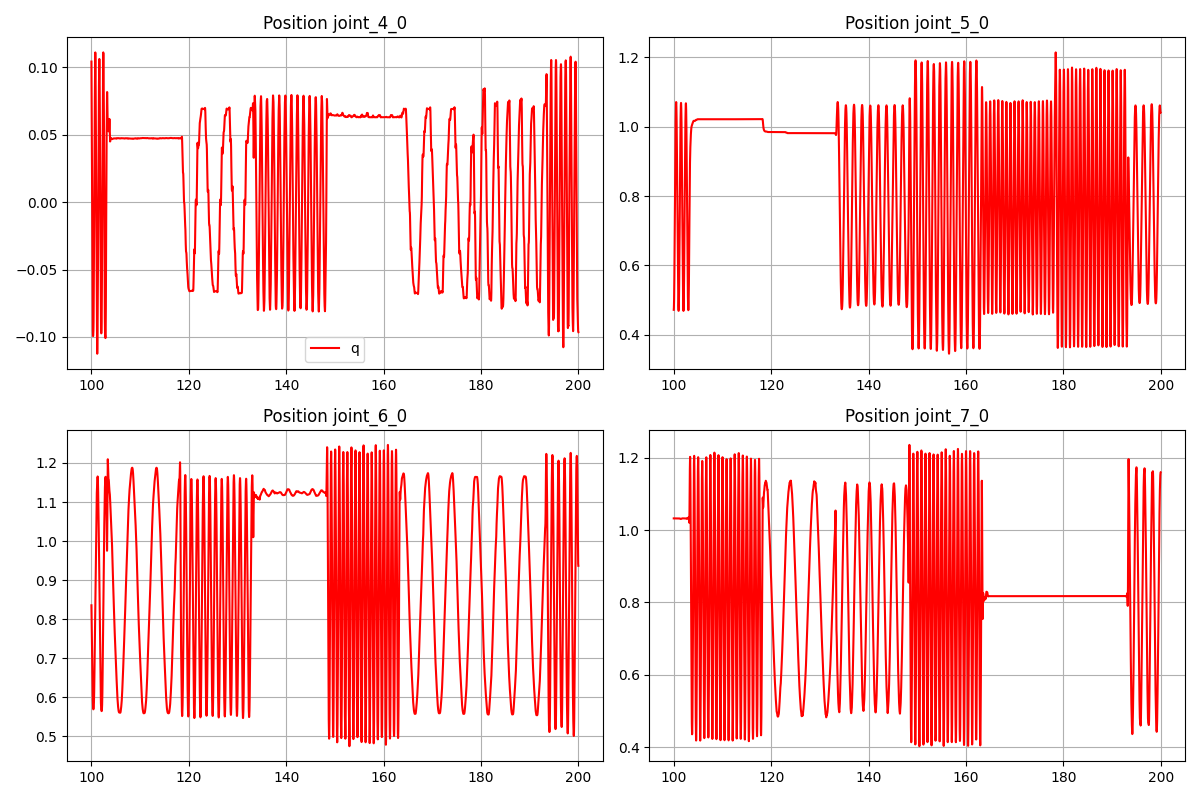

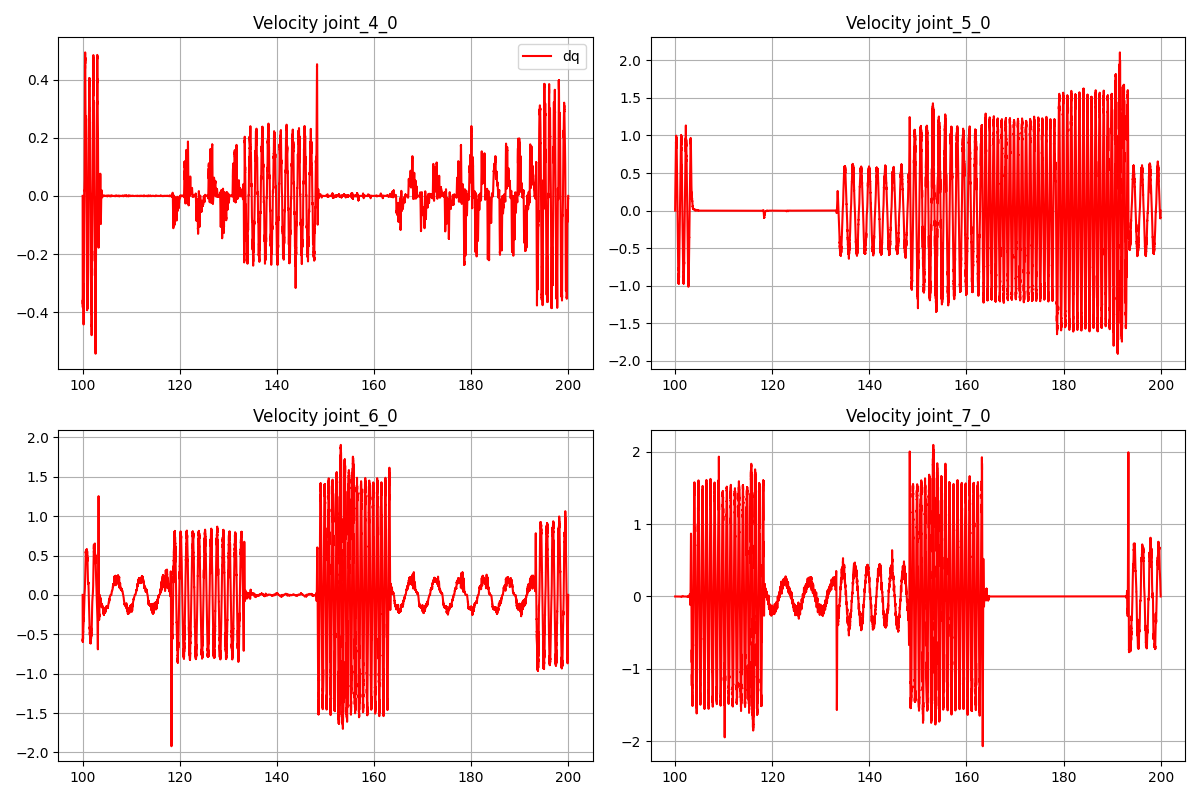

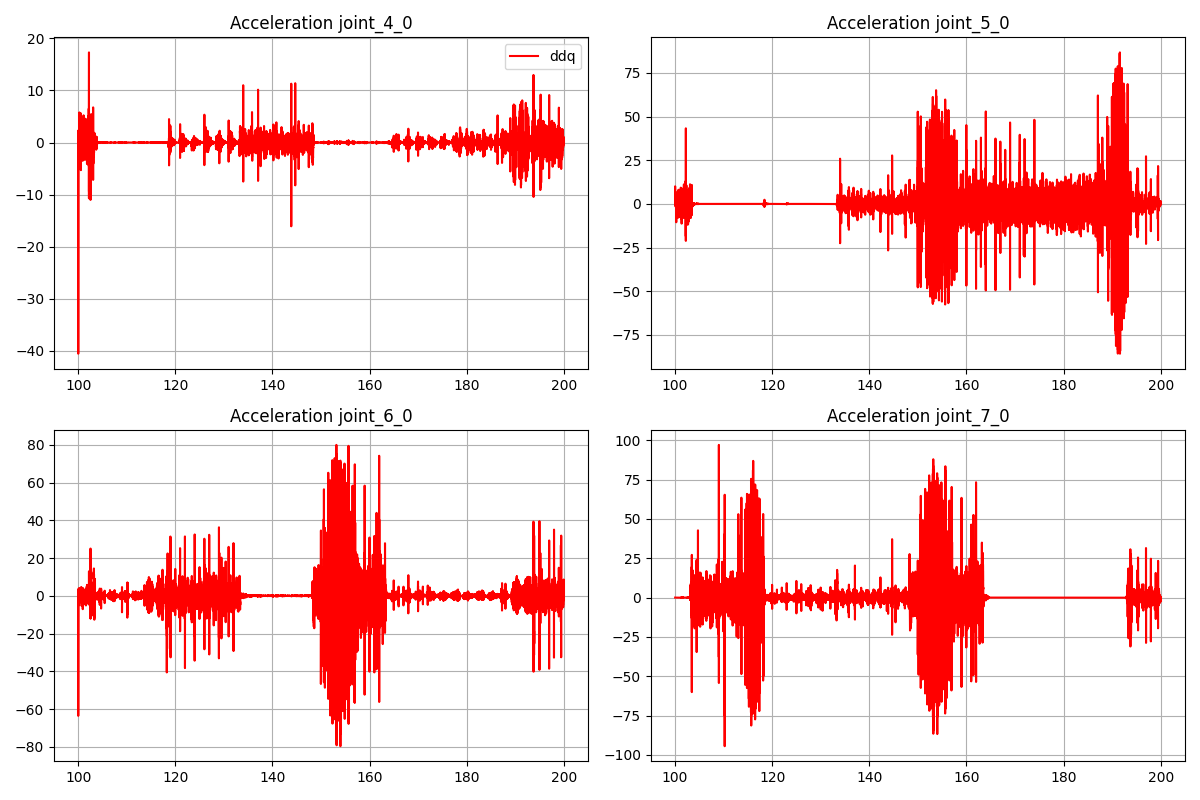

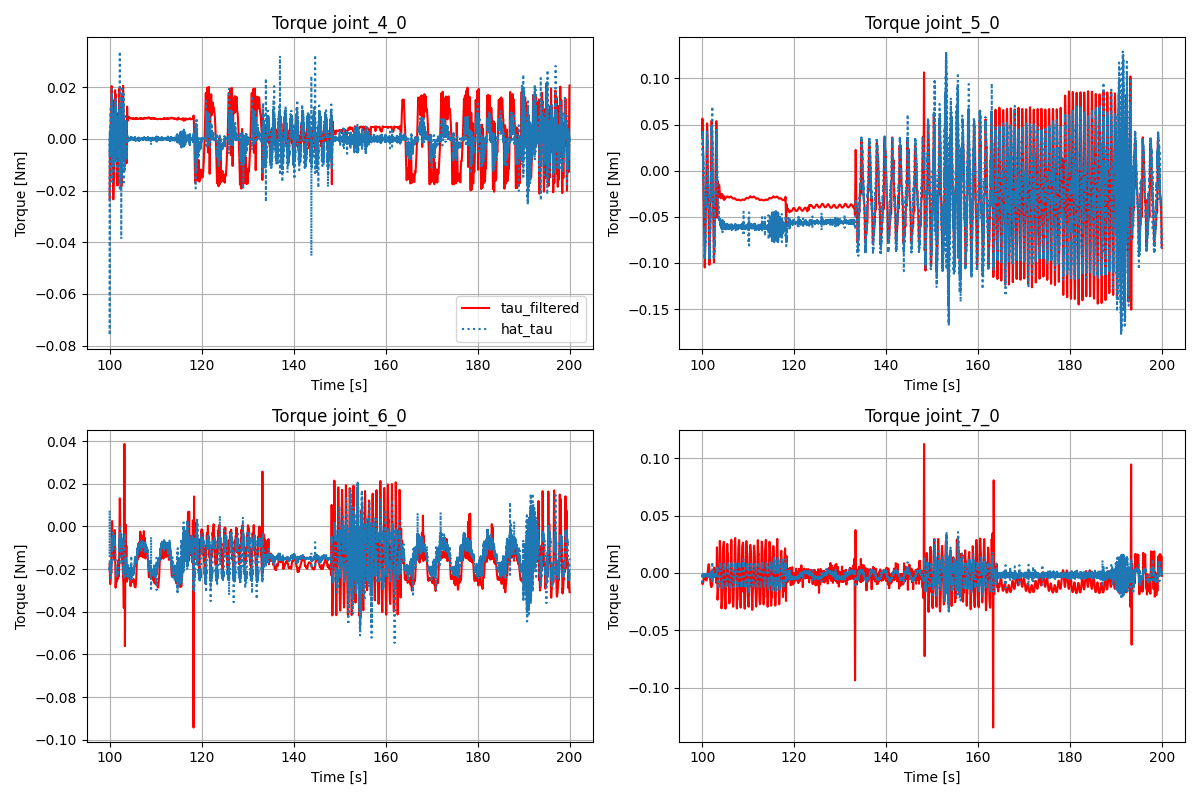

In [ ]:
delta_tau = []
for i in range(len(t_log)):
    #q =q_log[i,:]
    #dq = qd_log[i,:]
    #ddq = qdd_log[i,:]
    q = q_filt[i,:]
    dq = qd_filt[i,:]
    ddq = qdd_filt[i,:]

    thunder_ahand.set_q(q)
    thunder_ahand.set_dq(dq)
    thunder_ahand.set_dqr(dq)
    thunder_ahand.set_ddqr(ddq)
    Y = thunder_ahand.get_Yr()
    Y_hat = Y @ np.linalg.pinv(beta)
    # add friction damping and static
    Y_d = np.diag(dq.flatten())
    Y_s = np.diag((2/(1+np.exp(-20*dq)) - 1).flatten())
    # add rotor inertia
    Y_Ir = np.diag(ddq.flatten())

    Y = np.hstack([Y_hat, Y_d, Y_s])

    tau_est = np.array(Y @ hat_Pi).flatten()
    delta_tau.append(tau_filt[i,:] - tau_est)
delta_tau = np.array(delta_tau)


rmse = np.sqrt(np.mean(np.sum(delta_tau**2, axis=1))) # RMSE = Sqrt{ 1/M Sum{||e||_2}  }
print(f"RMSE: {rmse} Nm" )

# =========================================================================================================================== Plot
# --- 1. Plot joint trajectories ---
plt.figure(figsize=(12,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(t_log, q_log[:,i], 'r', label='q')
    plt.title(f'Position {JOINT_NAMES[i]}')
    plt.grid(True)
    if i==0:
        plt.legend()
plt.tight_layout()
plt.show()
plt.figure(figsize=(12,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(t_log, qd_log[:,i], 'r', label='dq')
    plt.title(f'Velocity {JOINT_NAMES[i]}')
    plt.grid(True)
    if i==0:
        plt.legend()
plt.tight_layout()
plt.show()
plt.figure(figsize=(12,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(t_log, qdd_filt[:,i], 'r', label='ddq')
    plt.title(f'Acceleration {JOINT_NAMES[i]}')
    plt.grid(True)
    if i==0:
        plt.legend()
plt.tight_layout()
plt.show()


# --- 1. Plot tau ---
plt.figure(figsize=(12,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    #plt.plot(t_log, tau_ori[:,i], label = 'tau')
    plt.plot(t_log, tau_log[:,i], 'r', label = 'tau_filtered')
    plt.plot(t_log, tau_log[:,i] - delta_tau[:,i], linestyle='dotted', label = 'hat_tau')
    plt.xlabel('Time [s]')
    plt.ylabel('Torque [Nm]')
    plt.title(f'Torque {JOINT_NAMES[i]}')
    plt.grid(True)
    if i==0:
        plt.legend()
plt.tight_layout()
plt.show(block=False)
